In [ ]:
import marimo as mo

# QoS-HRGN v2: Heterogeneous Adaptive Graph Learning for BraTS 3D Segmentation

**Pipeline**

`BraTS MRI → modality-specific 3D SLIC (T1ce / FLAIR partitions) → heterogeneous supervoxel graph → HGT → adaptive multi-hop propagation → pathology-aware prediction → voxel reconstruction`

**What changed from v1 (400-segment notebook) and why**

The v1 run showed node-level Dice ≈ 0.78 but voxel-level Dice of only WT 0.45 / TC 0.33 / ET 0.24.
That gap is a *graph-construction* problem, not a graph-learning problem. v2 fixes the construction:

| # | Change | Reason |
|---|---|---|
| 1 | `N_SEGMENTS` 400 → **15 000** (Saueressig et al. optimum on BraTS) | 400 supervoxels ≈ 15 mm bricks; ET is a thin rim of a few thousand voxels and cannot be drawn at that resolution. |
| 2 | Hard priority labels → **fractional (soft) labels** per node | Priority labelling made ET 3.7× more frequent than NCR at node level (opposite of reality) and painted whole bricks ET at reconstruction → low ET precision. |
| 3 | 6 single-modality features → **32 features from all four modalities** (mean, std, 5 quantiles each + position + size) | A T1ce node could not see FLAIR (edema) and vice-versa; T1/T2 were loaded and discarded. |
| 4 | Centroid-matched cross edges → **voxel-overlap cross edges** with overlap fraction as edge attribute | Overlap is the natural correspondence between two partitions of the same volume; gives 3–8 typed edges per node instead of 1. |
| 5 | **Oracle / ASA cells** | Reconstructing from ground-truth node labels shows the ceiling of a partition; if the ceiling is low the model cannot be blamed. |
| 6 | Model selection on **per-patient volume-weighted Dice** (= voxel Dice under node-constant predictions), ET small-volume post-processing, hidden 64→128, residual HGT, cosine LR, 80 epochs | v1 selected on batched node Dice which does not track voxel Dice. |

BraTS 2020 facts used here: 369 training cases (293 HGG, 76 LGG), 240×240×155 at 1 mm³, co-registered and skull-stripped; labels 0 = background, 1 = NCR/NET, 2 = ED, 4 = ET; evaluated on ET, TC = NCR/NET ∪ ET and WT = TC ∪ ED. Many LGG cases have **no ET at all**, which is why ET post-processing matters.

## 1. Imports and configuration

Every tunable lives in this cell. `N_SEGMENTS` and `COMPACTNESS` define the graph cache; changing either builds a new cache directory.

In [ ]:
# packages added via marimo's package management: torch-geometric nibabel scikit-image matplotlib kagglehub scipy joblib
import os, glob, re, random, time, math
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.segmentation import slic
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv
from torch_geometric.loader import DataLoader
from joblib import Parallel, delayed
import kagglehub

print("PyTorch:", torch.__version__)
try:
    import torch_geometric
    print("PyG:", torch_geometric.__version__)
except Exception:
    pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Graph construction ───────────────────────────────────────
N_SEGMENTS = 15000          # v1 used 400. Saueressig et al. (BraTS 2019/2021 GNN) found k≈15000 best by ASA.
COMPACTNESS = 0.3           # v1 used 0.1. Higher = more regular supervoxels. Sweep with the oracle cell if unsure.
SLIC_ITERS = 10             # v1 used 5.
MIN_OVERLAP = 0.05          # cross-modal edge kept if overlap/min(vol) >= this (best partner always kept).
NODE_TYPES = ("t1ce", "flair")                 # each defines its own SLIC partition (the heterogeneity)
MODALITIES = ("t1", "t1ce", "t2", "flair")     # every node summarises ALL four modalities
QUANTILES = (0.10, 0.25, 0.50, 0.75, 0.90)
NODE_FEAT_DIM = len(MODALITIES) * (2 + len(QUANTILES)) + 4   # 4*(mean,std,5 quantiles) + xyz + log-size = 32
GRAPH_VERSION = 2           # bump whenever the graph format changes; guards the cache

# ── Model / training ─────────────────────────────────────────
HIDDEN_DIM = 128
HEADS = 4
HGT_LAYERS = 2
HOPS = 2                    # adaptive propagation stages; set 0 for the "HGT only" ablation
DROPOUT = 0.1
EPOCHS = 80
BATCH_SIZE = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 1.0           # loss = soft-CE + DICE_WEIGHT * volume-weighted region Dice

# ── Evaluation ───────────────────────────────────────────────
ET_MIN_VOXELS = 300         # predicted ET smaller than this is relabelled NCR/NET (standard BraTS post-processing)

# ── Oracle sweep (set ORACLE_CASES = 0 to skip) ──────────────
ORACLE_CASES = 4
ORACLE_SWEEP = (400, 4000, 15000)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
if USE_AMP:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", device)
if USE_AMP:
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\n{'='*60}")
print(f"  QoS-HRGN v2 Config: N_SEGMENTS={N_SEGMENTS}  COMPACTNESS={COMPACTNESS}  FEATURES={NODE_FEAT_DIM}")
print(f"{'='*60}\n")

PyTorch: 2.11.0+cu130
PyG: 2.8.0.post1
Device: cpu

  QoS-HRGN v2 Config: N_SEGMENTS=15000  COMPACTNESS=0.3  FEATURES=32



## 1b. Option B configuration

In [ ]:
# ============================================================
# Option B: Structure-Aware Graph Refinement — configuration
# ------------------------------------------------------------
# Research ablation on top of the existing QoS-HRGN backbone. Set
# USE_STRUCTURAL_REFINEMENT = False to run the exact original baseline
# unchanged (nothing below in this cell affects that path). When True, an
# additional lightweight module analyses the STRUCTURE of the model's own
# predicted tumour graph -- not just node/edge features -- and uses it to
# refine the final classification (see the model cell below).
#
# We do NOT assume any structural relationship (e.g. "ET encloses NCR") is
# a universal biological rule. These are measurable graph properties the
# refinement module is free to learn to use, or to ignore.
USE_STRUCTURAL_REFINEMENT = False

# Individual descriptor toggles, so ablations can show WHICH structural
# signal (if any) actually helps.
STRUCTURAL_USE_NEIGHBOR_STATS = True    # tumour-neighbour / ET-neighbour fraction
STRUCTURAL_USE_DISTANCE = True          # hop-distance to nearest predicted ET / nearest predicted BG
STRUCTURAL_USE_COMPONENT_SIZE = True    # size of the predicted-tumour connected component
STRUCTURAL_USE_ENCLOSURE = True         # ET-neighbour fraction minus BG-neighbour fraction
STRUCTURAL_USE_CROSS_MODAL = True       # T1ce<->FLAIR correspondence fan-out

STRUCTURAL_HIDDEN = 32     # width of the structural MLP -- kept small on purpose
STRUCTURAL_DROPOUT = 0.1
STRUCTURAL_AUX_WEIGHT = 0.3   # loss = hierarchy_loss(final) + STRUCTURAL_AUX_WEIGHT * hierarchy_loss(initial)
                               # keeps the base model's OWN initial predictions well-calibrated,
                               # since the structural descriptors are derived from them, and avoids
                               # turning this into "a second, independent classifier."

# Scheduled sampling for structural context (the exposure-bias fix). Early in
# training, structural descriptors are computed mostly from ground-truth
# labels (a clean signal to bootstrap the refinement module). As training
# progresses we shift towards the model's OWN predicted labels, so the module
# learns to correct genuinely noisy structure rather than just to trust
# already-correct GT structure. GT is NEVER used for structural context
# outside of training -- validation/test always call with teacher_prob=0.0.
STRUCTURAL_TEACHER_PROB_START = 1.0
STRUCTURAL_TEACHER_PROB_END = 0.0

def structural_teacher_prob(epoch, total_epochs=EPOCHS):
    """Linear decay from STRUCTURAL_TEACHER_PROB_START to _END over training."""
    if total_epochs <= 1:
        return STRUCTURAL_TEACHER_PROB_END
    frac = min(max((epoch - 1) / (total_epochs - 1), 0.0), 1.0)
    return STRUCTURAL_TEACHER_PROB_START + (STRUCTURAL_TEACHER_PROB_END - STRUCTURAL_TEACHER_PROB_START) * frac

STRUCTURAL_FLAGS = dict(
    neighbor_stats=STRUCTURAL_USE_NEIGHBOR_STATS,
    distance=STRUCTURAL_USE_DISTANCE,
    component_size=STRUCTURAL_USE_COMPONENT_SIZE,
    enclosure=STRUCTURAL_USE_ENCLOSURE,
    cross_modal=STRUCTURAL_USE_CROSS_MODAL,
)

def structural_descriptor_dim(flags):
    dim = 0
    if flags["neighbor_stats"]:
        dim += 2   # tumour-neighbour fraction, ET-neighbour fraction
    if flags["distance"]:
        dim += 2   # hop-distance to nearest ET, hop-distance to nearest BG
    if flags["component_size"]:
        dim += 1   # log1p(tumour connected-component size), normalised
    if flags["enclosure"]:
        dim += 1   # ET-neighbour fraction minus BG-neighbour fraction
    if flags["cross_modal"]:
        dim += 1   # normalised cross-modal correspondence fan-out
    return dim

print(f"[Option B] USE_STRUCTURAL_REFINEMENT={USE_STRUCTURAL_REFINEMENT}  "
      f"structural_dim={structural_descriptor_dim(STRUCTURAL_FLAGS)}  flags={STRUCTURAL_FLAGS}")

[Option B] USE_STRUCTURAL_REFINEMENT=False  structural_dim=7  flags={'neighbor_stats': True, 'distance': True, 'component_size': True, 'enclosure': True, 'cross_modal': True}


## Local graph cache storage

Graphs (`*.graph.pt`, small, kept in RAM) and reconstruction metadata (`*.meta.pt`, large, loaded lazily) are stored separately.

In [ ]:
PERSISTENT_BASE = os.path.join(os.getcwd(), "brats_qos_hrgn_data")
GRAPH_CACHE_PATH = os.path.join(PERSISTENT_BASE, "graphs", f"slic_{N_SEGMENTS}_c{COMPACTNESS}_v{GRAPH_VERSION}")
os.makedirs(GRAPH_CACHE_PATH, exist_ok=True)
print(f"Graph cache directory: {GRAPH_CACHE_PATH}")

Graph cache directory: /marimo/brats_qos_hrgn_data/graphs/slic_15000_c0.3_v2


## Persistent storage — Hugging Face backend (optional)

Fill in `HF_TOKEN_PLACEHOLDER` below yourself, or set the `HF_TOKEN` environment variable in the runtime instead (the env var wins if both are set). **Do not commit this cell with a real token filled in** — the v1 notebook contained a live token in plain text; revoke it at https://huggingface.co/settings/tokens.

In [ ]:
HF_TOKEN_PLACEHOLDER = ""  # <- paste your token here yourself, or set the HF_TOKEN env var instead
HF_TOKEN = os.environ.get("HF_TOKEN") or HF_TOKEN_PLACEHOLDER
HF_ENABLED = bool(HF_TOKEN)
HF_REPO_ID = "marvelpokemaster/brats-qos-hrgn-graphs"
if HF_ENABLED:
    from huggingface_hub import login as _hf_login, HfApi as _HfApi
    _hf_login(token=HF_TOKEN)
    hf_api = _HfApi()
    hf_api.create_repo(repo_id=HF_REPO_ID, repo_type="dataset", private=False, exist_ok=True)
    os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"
    print(f"Hugging Face ready: {HF_REPO_ID}")
else:
    hf_api = None
    print("No HF token (placeholder empty, HF_TOKEN env var unset); Hugging Face backend disabled.")

Hugging Face ready: marvelpokemaster/brats-qos-hrgn-graphs


## 2. Download / discover BraTS 2020 data

The Kaggle mirror ships 369 training cases; `BraTS20_Training_355` has a mis-named segmentation file (`W39_1998.09.19_Segm.nii`), which v1 silently dropped. The regex below accepts it, so all 369 are usable.

In [ ]:
DATASET_SLUG = "awsaf49/brats20-dataset-training-validation"
dataset_root = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset:", dataset_root)

def modality_kind(path):
    name = os.path.basename(path).lower()
    if re.search(r"(^|[_-])t1ce([_.-]|$)", name):
        return "t1ce"
    if re.search(r"(^|[_-])flair([_.-]|$)", name):
        return "flair"
    if re.search(r"(^|[_-])t2([_.-]|$)", name):
        return "t2"
    if re.search(r"(^|[_-])t1([_.-]|$)", name):
        return "t1"
    if re.search(r"(^|[_-])(seg|segm|mask)([_.-]|$)", name):
        return "seg"
    return None

all_nii = glob.glob(os.path.join(dataset_root, "**", "*.nii"), recursive=True)
all_nii = all_nii + glob.glob(os.path.join(dataset_root, "**", "*.nii.gz"), recursive=True)
case_map = {}
for _p in all_nii:
    _k = modality_kind(_p)
    if _k:
        case_map.setdefault(os.path.dirname(_p), {})[_k] = _p
valid_cases_all = sorted(
    (d, m) for d, m in case_map.items() if all(k in m for k in ("t1", "t1ce", "t2", "flair", "seg"))
)
valid_cases_all = [(d, m) for d, m in valid_cases_all if "training" in d.lower()] or valid_cases_all
MAX_CASES = None   # set to a small int while debugging
valid_cases = valid_cases_all if MAX_CASES is None else valid_cases_all[:MAX_CASES]
print("Complete cases available:", len(valid_cases_all))
print("Cases selected:", len(valid_cases))

 38%|███▊      | 1.58G/4.16G [00:20<01:18, 35.4MB/s]

## 3. Utility functions

Each modality is z-scored inside the brain mask. SLIC is only a **regionalisation step**; labels are voxel fractions per node.

In [ ]:
def load_nii(path):
    return nib.load(path).get_fdata().astype(np.float32)

def normalize_brain(vol):
    mask = vol > 0
    out = np.zeros_like(vol, dtype=np.float32)
    if mask.any():
        vals = vol[mask]
        out[mask] = (vals - vals.mean()) / (vals.std() + 1e-8)
    return out

CLASS_NAMES = ["BG", "NCR/NET", "ED", "ET"]
NUM_CLASSES = 4

def remap_labels(seg):
    # BraTS raw labels 0/1/2/4 -> 0/1/2/3
    out = np.zeros(seg.shape, dtype=np.uint8)
    out[seg == 1] = 1
    out[seg == 2] = 2
    out[seg == 4] = 3
    return out

def load_case(files):
    vols = {m: load_nii(files[m]) for m in MODALITIES}
    brain = np.zeros(vols["t1"].shape, dtype=bool)
    for m in MODALITIES:
        brain |= vols[m] > 0
    vols = {m: normalize_brain(v) for m, v in vols.items()}
    seg = remap_labels(load_nii(files["seg"]).round().astype(np.int64))
    return vols, seg, brain

def crop_bounds(brain):
    coords = np.argwhere(brain)
    return coords.min(axis=0), coords.max(axis=0) + 1

def crop(vol, lo, hi):
    return vol[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]]

def dice_binary(pred, target, eps=1e-6):
    pred = pred.astype(bool)
    target = target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def segmentation_metrics(pred, target):
    # pred/target use 0,1,2,3 where 1=NCR/NET, 2=ED, 3=ET
    wt_p, wt_t = pred > 0, target > 0
    tc_p, tc_t = np.logical_or(pred == 1, pred == 3), np.logical_or(target == 1, target == 3)
    et_p, et_t = pred == 3, target == 3
    return {
        "Dice_WT": dice_binary(wt_p, wt_t),
        "Dice_TC": dice_binary(tc_p, tc_t),
        "Dice_ET": dice_binary(et_p, et_t),
    }

def postprocess_prediction(pred, et_min_voxels=ET_MIN_VOXELS):
    """Standard BraTS trick: a tiny predicted ET is almost always a false positive
    (LGG cases often have no ET). Relabel it as NCR/NET so TC is preserved."""
    et = pred == 3
    n_et = int(et.sum())
    if 0 < n_et < et_min_voxels:
        pred = pred.copy()
        pred[et] = 1
    return pred

def fmt_metrics(m):
    return f"WT={m['Dice_WT']:.4f} | TC={m['Dice_TC']:.4f} | ET={m['Dice_ET']:.4f}"

## 4. Build the heterogeneous supervoxel graph (vectorised)

Two node types, each a separate SLIC partition of the *same* cropped brain:

- `t1ce`: supervoxels whose boundaries follow T1ce contrast (ET / NCR boundaries).
- `flair`: supervoxels whose boundaries follow FLAIR contrast (edema boundary).

Relations:

- `t1ce --spatial--> t1ce`, `flair --spatial--> flair`: face-adjacent supervoxels. Edge attributes `[normalised centroid distance, normalised shared-face count]`.
- `t1ce --corresponds--> flair` and back: supervoxels that **overlap in voxel space**. Edge attributes `[normalised centroid distance, overlap / min(volume)]`.

Per node (32 features): for each of T1, T1ce, T2, FLAIR → mean, std and the 10/25/50/75/90 % quantiles of the voxels inside the supervoxel; plus normalised centroid (3) and log relative volume (1).

Per node targets: `y_frac` (fraction of voxels in each of BG / NCR-NET / ED / ET), `y` (majority class, for reporting only), `vol` (fraction of brain voxels, used to volume-weight the Dice loss so it equals voxel Dice).

Everything is `bincount`/`lexsort` based — no per-supervoxel Python loops — so 15 000 nodes cost about the same as 400 did in v1.

In [ ]:
def _label_mean_std(lab, vals, K):
    cnt = np.bincount(lab, minlength=K).astype(np.float64)
    s1 = np.bincount(lab, weights=vals, minlength=K)
    s2 = np.bincount(lab, weights=vals * vals, minlength=K)
    mean = s1 / np.maximum(cnt, 1)
    var = np.maximum(s2 / np.maximum(cnt, 1) - mean * mean, 0.0)
    return mean, np.sqrt(var)

def _label_quantiles(lab, vals, K, qs):
    order = np.lexsort((vals, lab))            # sort by label, then value
    lab_s, vals_s = lab[order], vals[order]
    cnt = np.bincount(lab_s, minlength=K)
    starts = np.concatenate(([0], np.cumsum(cnt)[:-1]))
    out = np.empty((K, len(qs)), dtype=np.float64)
    for qi, q in enumerate(qs):
        pos = starts + np.floor(q * np.maximum(cnt - 1, 0)).astype(np.int64)
        out[:, qi] = vals_s[np.minimum(pos, len(vals_s) - 1)]
    return out

def slic_node_map(vol_c, brain_c, n_segments, compactness, max_iter):
    """Run SLIC inside the brain mask; return an int32 array of node indices (-1 outside the brain)."""
    segments = slic(
        vol_c, n_segments=n_segments, compactness=compactness, max_num_iter=max_iter,
        start_label=1, mask=brain_c, channel_axis=None,
    )
    ids = np.unique(segments[brain_c])
    lut = np.full(int(segments.max()) + 1, -1, dtype=np.int32)
    lut[ids] = np.arange(len(ids), dtype=np.int32)
    node_map = lut[segments]
    node_map[~brain_c] = -1
    return node_map, int(len(ids))

def node_table(node_map, brain_c, vols_c, seg_c):
    lab = node_map[brain_c].astype(np.int64)
    K = int(lab.max()) + 1
    cnt = np.bincount(lab, minlength=K).astype(np.float64)

    feats = []
    for m in MODALITIES:
        v = vols_c[m][brain_c].astype(np.float64)
        mean, std = _label_mean_std(lab, v, K)
        feats += [mean[:, None], std[:, None], _label_quantiles(lab, v, K, QUANTILES)]

    xyz = np.argwhere(brain_c).astype(np.float64)          # same C-order as node_map[brain_c]
    cent = np.stack([np.bincount(lab, weights=xyz[:, a], minlength=K) / cnt for a in range(3)], axis=1)
    cent_n = cent / np.asarray(brain_c.shape, dtype=np.float64)
    vol_frac = cnt / cnt.sum()
    feats += [cent_n, np.log(vol_frac * K)[:, None]]        # log relative size (0 = average node)
    x = np.concatenate(feats, axis=1).astype(np.float32)

    cls = seg_c[brain_c].astype(np.int64)
    y_frac = np.bincount(lab * NUM_CLASSES + cls, minlength=K * NUM_CLASSES).reshape(K, NUM_CLASSES)
    y_frac = (y_frac / cnt[:, None]).astype(np.float32)
    return dict(x=x, y_frac=y_frac, vol=vol_frac.astype(np.float32), cent=cent.astype(np.float32), cnt=cnt, K=K)

def spatial_edges(node_map, cent, K):
    keys = []
    for axis in range(3):
        a_sl = [slice(None)] * 3
        b_sl = [slice(None)] * 3
        a_sl[axis] = slice(0, -1)
        b_sl[axis] = slice(1, None)
        a, b = node_map[tuple(a_sl)], node_map[tuple(b_sl)]
        valid = (a >= 0) & (b >= 0) & (a != b)
        u, v = a[valid].astype(np.int64), b[valid].astype(np.int64)
        keys.append(u * K + v)
        keys.append(v * K + u)
    keys, faces = np.unique(np.concatenate(keys), return_counts=True)
    u, v = keys // K, keys % K
    dist = np.linalg.norm(cent[u] - cent[v], axis=1)
    attr = np.stack([dist / (dist.mean() + 1e-8), faces / (faces.mean() + 1e-8)], axis=1).astype(np.float32)
    return np.stack([u, v]).astype(np.int64), attr

def overlap_edges(map_a, map_b, brain_c, tab_a, tab_b, min_overlap=MIN_OVERLAP):
    la = map_a[brain_c].astype(np.int64)
    lb = map_b[brain_c].astype(np.int64)
    Kb = tab_b["K"]
    keys, n_shared = np.unique(la * Kb + lb, return_counts=True)
    i, j = keys // Kb, keys % Kb
    overlap = n_shared / np.minimum(tab_a["cnt"][i], tab_b["cnt"][j])

    def _best(group):                       # mark the strongest partner of every node in `group`
        order = np.lexsort((-n_shared, group))
        first = np.ones(len(group), dtype=bool)
        first[1:] = group[order][1:] != group[order][:-1]
        mark = np.zeros(len(group), dtype=bool)
        mark[order[first]] = True
        return mark

    keep = (overlap >= min_overlap) | _best(i) | _best(j)
    i, j, overlap = i[keep], j[keep], overlap[keep]
    dist = np.linalg.norm(tab_a["cent"][i] - tab_b["cent"][j], axis=1)
    attr = np.stack([dist / (dist.mean() + 1e-8), overlap], axis=1).astype(np.float32)
    return np.stack([i, j]).astype(np.int64), attr

def build_hetero_case(files, n_segments=N_SEGMENTS, compactness=COMPACTNESS, max_iter=SLIC_ITERS):
    vols, seg, brain = load_case(files)
    lo, hi = crop_bounds(brain)
    brain_c = crop(brain, lo, hi)
    seg_c = crop(seg, lo, hi)
    vols_c = {m: crop(v, lo, hi) for m, v in vols.items()}

    parts = {}
    for nt in NODE_TYPES:
        node_map, K = slic_node_map(vols_c[nt], brain_c, n_segments, compactness, max_iter)
        tab = node_table(node_map, brain_c, vols_c, seg_c)
        ei, ea = spatial_edges(node_map, tab["cent"], K)
        parts[nt] = dict(node_map=node_map, tab=tab, ei=ei, ea=ea)

    cross_ei, cross_ea = overlap_edges(
        parts["t1ce"]["node_map"], parts["flair"]["node_map"], brain_c,
        parts["t1ce"]["tab"], parts["flair"]["tab"],
    )

    data = HeteroData()
    for nt in NODE_TYPES:
        tab = parts[nt]["tab"]
        data[nt].x = torch.from_numpy(tab["x"])
        data[nt].y_frac = torch.from_numpy(tab["y_frac"])
        data[nt].y = torch.from_numpy(tab["y_frac"].argmax(axis=1).astype(np.int64))
        data[nt].vol = torch.from_numpy(tab["vol"])
        data[nt, "spatial", nt].edge_index = torch.from_numpy(parts[nt]["ei"])
        data[nt, "spatial", nt].edge_attr = torch.from_numpy(parts[nt]["ea"])
    data["t1ce", "corresponds", "flair"].edge_index = torch.from_numpy(cross_ei)
    data["t1ce", "corresponds", "flair"].edge_attr = torch.from_numpy(cross_ea)
    data["flair", "corresponds", "t1ce"].edge_index = torch.from_numpy(cross_ei[::-1].copy())
    data["flair", "corresponds", "t1ce"].edge_attr = torch.from_numpy(cross_ea.copy())

    meta = {
        "seg": seg.astype(np.uint8),
        "lo": lo, "hi": hi,
        "crop_shape": tuple(brain_c.shape),
        "original_shape": tuple(seg.shape),
        "node_map": {nt: parts[nt]["node_map"].astype(np.int32) for nt in NODE_TYPES},
        "vis": {nt: vols_c[nt].astype(np.float16) for nt in NODE_TYPES},
    }
    return data, meta

## 5. Voxel reconstruction and the oracle (achievable segmentation accuracy)

`project_node_probs` paints each node's 4-class probability vector onto its supervoxel for both partitions, averages where both cover a voxel, and takes the arg-max.

The **oracle** feeds the *ground-truth* node fractions through the same projection. Its Dice is the upper bound any node classifier can reach on this partition. If the oracle is low, the fix is graph construction, not the model.

In [ ]:
def project_node_probs(node_probs, meta):
    crop_shape = tuple(meta["crop_shape"])
    acc = np.zeros(crop_shape + (NUM_CLASSES,), dtype=np.float32)
    count = np.zeros(crop_shape, dtype=np.float32)
    for nt, probs in node_probs.items():
        nm = meta["node_map"][nt]
        valid = nm >= 0
        acc[valid] += np.asarray(probs, dtype=np.float32)[nm[valid]]
        count[valid] += 1.0
    valid = count > 0
    acc[valid] /= count[valid, None]
    pred_c = acc.argmax(axis=-1).astype(np.uint8)
    pred_c[~valid] = 0
    pred = np.zeros(tuple(meta["original_shape"]), dtype=np.uint8)
    lo, hi = meta["lo"], meta["hi"]
    pred[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] = pred_c
    return pred

def oracle_prediction(data, meta, soft=False):
    """Reconstruction from ground-truth node labels. soft=True averages the class
    fractions; soft=False uses one-hot majority labels (what a perfect hard classifier gives)."""
    node_probs = {}
    for nt in NODE_TYPES:
        yf = data[nt].y_frac.cpu().numpy()
        node_probs[nt] = yf if soft else np.eye(NUM_CLASSES, dtype=np.float32)[yf.argmax(axis=1)]
    return project_node_probs(node_probs, meta)

def oracle_metrics(data, meta, soft=False):
    return segmentation_metrics(oracle_prediction(data, meta, soft=soft), meta["seg"])

@torch.no_grad()
def predict_node_probs(model, data):
    """Baseline-compatible: returns the FINAL prediction (identical to the
    plain model output when USE_STRUCTURAL_REFINEMENT=False; the refined
    prediction otherwise). Used by reconstruct_case/evaluate_items below,
    which therefore keeps reporting the same WT/TC/ET metrics either way.
    See predict_node_probs_both (Option B cell) for initial-vs-refined."""
    model.eval()
    dev = next(model.parameters()).device
    if USE_STRUCTURAL_REFINEMENT:
        _, logits, _ = model(data.to(dev), teacher_prob=0.0)  # never GT at eval
    else:
        logits, _ = model(data.to(dev))
    return {nt: torch.softmax(logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}

def reconstruct_case(model, data, meta, postprocess=True):
    pred = project_node_probs(predict_node_probs(model, data), meta)
    return postprocess_prediction(pred) if postprocess else pred

## 6. Oracle sweep over the number of supervoxels

Runs SLIC at several `n_segments` on a handful of cases and reports the ceiling Dice, node count and build time. Use this to justify `N_SEGMENTS` (Saueressig et al. tuned exactly this quantity, calling it ASA). Set `ORACLE_CASES = 0` in the config cell to skip.

In [ ]:
def partition_ceiling(files, n_segments, compactness):
    t0 = time.time()
    d, m = build_hetero_case(files, n_segments=n_segments, compactness=compactness)
    row = dict(case=os.path.basename(os.path.dirname(files["t1"])), k=n_segments,
               nodes=int(d["t1ce"].x.size(0)), secs=time.time() - t0)
    row.update({f"hard_{k[5:]}": v for k, v in oracle_metrics(d, m, soft=False).items()})
    row.update({f"soft_{k[5:]}": v for k, v in oracle_metrics(d, m, soft=True).items()})
    return row

oracle_rows = []
if ORACLE_CASES and ORACLE_SWEEP:
    _step = max(1, len(valid_cases) // ORACLE_CASES)
    _sweep_cases = [files for _, files in valid_cases[::_step][:ORACLE_CASES]]
    _tasks = [(f, k) for f in _sweep_cases for k in ORACLE_SWEEP]
    print(f"Oracle sweep: {len(_sweep_cases)} cases x {list(ORACLE_SWEEP)} segments ...")
    oracle_rows = Parallel(n_jobs=min(len(_tasks), os.cpu_count() or 4), backend="loky")(
        delayed(partition_ceiling)(f, k, COMPACTNESS) for f, k in _tasks
    )
    print(f"\n{'k':>7} | {'nodes':>6} | {'sec':>5} | {'oracle hard WT/TC/ET':^26} | {'oracle soft WT/TC/ET':^26}")
    print("-" * 85)
    for _k in ORACLE_SWEEP:
        _rs = [r for r in oracle_rows if r["k"] == _k]
        _mean = lambda key: np.mean([r[key] for r in _rs])
        print(f"{_k:>7} | {_mean('nodes'):>6.0f} | {_mean('secs'):>5.0f} | "
              f"{_mean('hard_WT'):.3f} / {_mean('hard_TC'):.3f} / {_mean('hard_ET'):.3f}       | "
              f"{_mean('soft_WT'):.3f} / {_mean('soft_TC'):.3f} / {_mean('soft_ET'):.3f}")
    print("\nThe oracle is the ceiling for a perfect node classifier on that partition.")
else:
    print("Oracle sweep skipped (ORACLE_CASES=0).")

Oracle sweep: 4 cases x [400, 4000, 15000] segments ...

      k |  nodes |   sec |    oracle hard WT/TC/ET    |    oracle soft WT/TC/ET   
-------------------------------------------------------------------------------------
    400 |    400 |    20 | 0.681 / 0.535 / 0.378       | 0.696 / 0.550 / 0.406
   4000 |   4000 |   106 | 0.821 / 0.801 / 0.652       | 0.832 / 0.814 / 0.682
  15000 |  15000 |   324 | 0.883 / 0.869 / 0.756       | 0.888 / 0.877 / 0.773

The oracle is the ceiling for a perfect node classifier on that partition.


## 7. Inspect one heterogeneous graph

In [ ]:
sample_data, sample_meta = build_hetero_case(valid_cases[0][1])
print(sample_data)
print("\nMetadata:", sample_data.metadata())
for _nt in sample_data.node_types:
    _yf = sample_data[_nt].y_frac
    print(f"{_nt}: nodes={_yf.size(0)}  pure nodes={(float((_yf.max(dim=1).values > 0.999).float().mean()) * 100):.1f}%  "
          f"class voxel-fraction={[round(float(v), 4) for v in (sample_data[_nt].vol[:, None] * _yf).sum(0)]}")
for _et in sample_data.edge_types:
    print(_et, "edges:", sample_data[_et].edge_index.shape[1])
print("\nOracle on this case (hard):", fmt_metrics(oracle_metrics(sample_data, sample_meta)))
print("Oracle on this case (soft):", fmt_metrics(oracle_metrics(sample_data, sample_meta, soft=True)))

HeteroData(
  t1ce={
    x=[15000, 32],
    y_frac=[15000, 4],
    y=[15000],
    vol=[15000],
  },
  flair={
    x=[15000, 32],
    y_frac=[15000, 4],
    y=[15000],
    vol=[15000],
  },
  (t1ce, spatial, t1ce)={
    edge_index=[2, 197078],
    edge_attr=[197078, 2],
  },
  (flair, spatial, flair)={
    edge_index=[2, 197094],
    edge_attr=[197094, 2],
  },
  (t1ce, corresponds, flair)={
    edge_index=[2, 16063],
    edge_attr=[16063, 2],
  },
  (flair, corresponds, t1ce)={
    edge_index=[2, 16063],
    edge_attr=[16063, 2],
  }
)

Metadata: (['t1ce', 'flair'], [('t1ce', 'spatial', 't1ce'), ('flair', 'spatial', 'flair'), ('t1ce', 'corresponds', 'flair'), ('flair', 'corresponds', 't1ce')])
t1ce: nodes=15000  pure nodes=83.9%  class voxel-fraction=[0.8421, 0.0115, 0.1257, 0.0207]
flair: nodes=15000  pure nodes=84.1%  class voxel-fraction=[0.8421, 0.0115, 0.1257, 0.0207]
('t1ce', 'spatial', 't1ce') edges: 197078
('flair', 'spatial', 'flair') edges: 197094
('t1ce', 'corresponds', 'fla

## 8. HGT + adaptive multi-hop propagation

### HGT
`HGTConv` is the heterogeneous backbone: separate node types, typed relations. v2 wraps each layer with a residual connection and LayerNorm so two layers train stably at `hidden_dim=128`.

### Adaptive propagation
After HGT, an adaptive message weight is computed for every edge from

- source / destination embeddings
- the edge attributes (distance and contact/overlap strength)
- feature cosine similarity
- cross-modal relation indicator
- current prediction uncertainty (normalised entropy)

Messages are gate-normalised (attention-style) rather than summed raw. Applied `HOPS` times, so information can travel beyond immediate neighbours. Set `HOPS = 0` for the *HGT-only* ablation.

In [ ]:
class AdaptiveHeteroPropagation(nn.Module):
    def __init__(self, hidden_dim, edge_types, node_types, edge_attr_dim=2, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.msg = nn.ModuleDict()
        self.gate = nn.ModuleDict()
        for et in edge_types:
            key = "__".join(et)
            self.msg[key] = nn.Linear(hidden_dim, hidden_dim)
            # source + destination + edge attributes + [similarity, cross-modal flag, uncertainty]
            self.gate[key] = nn.Sequential(
                nn.Linear(hidden_dim * 2 + edge_attr_dim + 3, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1),
            )
        self.norm = nn.ModuleDict({nt: nn.LayerNorm(hidden_dim) for nt in node_types})
        self.drop = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict, logits_dict):
        out = {nt: torch.zeros(x.size(0), x.size(1), device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}
        denom = {nt: torch.zeros(x.size(0), 1, device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}

        unc = {}
        for nt, logits in logits_dict.items():
            p = torch.softmax(logits.float(), dim=-1).clamp_min(1e-8)
            unc[nt] = -(p * p.log()).sum(dim=-1) / math.log(p.size(-1))

        for et in self.edge_types:
            src_t, rel, dst_t = et
            key = "__".join(et)
            ei = edge_index_dict[et]
            if ei.numel() == 0:
                continue
            src, dst = ei
            hs = x_dict[src_t][src].float()
            hd = x_dict[dst_t][dst].float()
            ea = edge_attr_dict[et].float()
            sim = F.cosine_similarity(hs, hd, dim=-1).unsqueeze(1)
            cross = torch.full((ea.size(0), 1), 1.0 if rel == "corresponds" else 0.0, device=hs.device)
            u = ((unc[src_t][src] + unc[dst_t][dst]) / 2).unsqueeze(1)

            alpha = torch.sigmoid(self.gate[key](torch.cat([hs, hd, ea, sim, cross, u], dim=1))).float()
            msg = (self.msg[key](hs).float() * alpha)
            out[dst_t].index_add_(0, dst, msg)
            denom[dst_t].index_add_(0, dst, alpha)

        return {
            nt: self.norm[nt](x_dict[nt].float() + self.drop(F.relu(out[nt] / (denom[nt] + 1.0))))
            for nt in x_dict
        }


class QoSHRGN(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, num_classes=4, hops=2, hgt_layers=2, dropout=0.1):
        super().__init__()
        self.metadata = (
            list(NODE_TYPES),
            [
                ("t1ce", "spatial", "t1ce"),
                ("flair", "spatial", "flair"),
                ("t1ce", "corresponds", "flair"),
                ("flair", "corresponds", "t1ce"),
            ],
        )
        self.input_proj = nn.ModuleDict({
            nt: nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim))
            for nt in NODE_TYPES
        })
        self.hgt = nn.ModuleList([
            HGTConv(in_channels=hidden_dim, out_channels=hidden_dim, metadata=self.metadata, heads=heads)
            for _ in range(hgt_layers)
        ])
        self.hgt_norm = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_dim) for nt in NODE_TYPES}) for _ in range(hgt_layers)
        ])
        self.pre_head = nn.ModuleDict({nt: nn.Linear(hidden_dim, num_classes) for nt in NODE_TYPES})
        self.adaptive = nn.ModuleList([
            AdaptiveHeteroPropagation(hidden_dim, self.metadata[1], self.metadata[0], edge_attr_dim=2, dropout=dropout)
            for _ in range(hops)
        ])
        self.final_head = nn.ModuleDict({nt: nn.Linear(hidden_dim, num_classes) for nt in NODE_TYPES})
        self.drop = nn.Dropout(dropout)

    def forward(self, data):
        x_dict = {nt: self.input_proj[nt](data[nt].x) for nt in NODE_TYPES}
        edge_index_dict = {et: data[et].edge_index for et in self.metadata[1]}
        edge_attr_dict = {et: data[et].edge_attr for et in self.metadata[1]}

        for conv, norms in zip(self.hgt, self.hgt_norm):
            h = conv(x_dict, edge_index_dict)
            x_dict = {nt: norms[nt](x_dict[nt] + self.drop(F.relu(h[nt]))) for nt in x_dict}

        # Initial prediction supplies uncertainty to adaptive propagation.
        logits_dict = {nt: self.pre_head[nt](x_dict[nt]) for nt in x_dict}
        for layer in self.adaptive:
            x_dict = layer(x_dict, edge_index_dict, edge_attr_dict, logits_dict)
            logits_dict = {nt: self.pre_head[nt](x_dict[nt]) for nt in x_dict}

        final_logits = {nt: self.final_head[nt](x_dict[nt]) for nt in x_dict}
        return final_logits, x_dict

## 9b. Option B: structure-aware graph refinement (research ablation)

After the base model's HGT + adaptive propagation produce initial node predictions, this optional module analyses the STRUCTURE of that predicted tumour graph (neighbour-class fractions, hop-distance to nearest ET/BG, tumour connected-component size, enclosure score, cross-modal fan-out) and uses it to refine the final classification. Disabled by default (`USE_STRUCTURAL_REFINEMENT = False`); the baseline model/training/eval below is completely unaffected when disabled.

In [ ]:
# ============================================================
# Option B: structural descriptor computation (graph algorithms)
# ------------------------------------------------------------
# Descriptors are computed on the SPATIAL graph of a single node type
# (t1ce-spatial-t1ce or flair-spatial-flair) using a TEMPORARY discrete
# predicted class per node (mixed with GT via scheduled sampling during
# training only -- see StructuralQoSHRGN.forward). These are graph-algorithm
# operations (BFS, connected components) on a discrete label graph; they run
# on detached tensors via scipy sparse routines and are NOT part of the
# autograd graph. Gradients still reach the refinement module through the
# continuous embeddings/probabilities (h, p) that accompany the descriptors.
import scipy.sparse as sp
from scipy.sparse.csgraph import shortest_path, connected_components

_STRUCT_DIST_SENTINEL = 16.0   # finite "far / not present in this graph" hop-distance

def _edge_index_to_csr(edge_index, num_nodes):
    if edge_index.numel() == 0:
        return sp.csr_matrix((num_nodes, num_nodes), dtype=np.float32)
    ei = edge_index.detach().cpu().numpy()
    data = np.ones(ei.shape[1], dtype=np.float32)
    return sp.csr_matrix((data, (ei[0], ei[1])), shape=(num_nodes, num_nodes))

def _multi_source_hop_distance(csr, seed_mask_np, sentinel=_STRUCT_DIST_SENTINEL):
    """Hop-distance from the nearest True node in seed_mask_np to every node,
    via a virtual super-source connected to all seeds (standard multi-source
    BFS trick): ONE sparse shortest-path call regardless of how many seed
    nodes there are -- no all-pairs shortest paths, no dense NxN matrix.
    Nodes with no reachable seed (e.g. no ET anywhere in this patient's
    graph) get the finite `sentinel` value, never inf/NaN."""
    n = csr.shape[0]
    seed_idx = np.nonzero(seed_mask_np)[0]
    if seed_idx.size == 0:
        return np.full(n, sentinel, dtype=np.float32)
    src_row = sp.csr_matrix(
        (np.ones(seed_idx.size, dtype=np.float32), (np.zeros(seed_idx.size, dtype=np.int64), seed_idx)),
        shape=(1, n),
    )
    aug = sp.vstack([
        sp.hstack([csr, src_row.T]),
        sp.hstack([src_row, sp.csr_matrix((1, 1), dtype=np.float32)]),
    ]).tocsr()
    d = shortest_path(aug, method="D", directed=False, unweighted=True, indices=n)
    d = d[:n] - 1.0                     # subtract the virtual source -> seed hop
    d[~np.isfinite(d)] = sentinel
    d = np.clip(d, 0.0, sentinel)
    return d.astype(np.float32)

def _tumour_component_sizes(csr, tumour_mask_np):
    """Size of the connected component (within the SPATIAL graph, restricted
    to predicted-tumour nodes) that each tumour node belongs to. Non-tumour
    nodes get 0. Uses the spatial graph only, per spec."""
    n = csr.shape[0]
    idx = np.nonzero(tumour_mask_np)[0]
    sizes = np.zeros(n, dtype=np.float32)
    if idx.size == 0:
        return sizes
    sub = csr[idx][:, idx]
    n_comp, labels = connected_components(sub, directed=False)
    comp_sizes = np.bincount(labels, minlength=n_comp)
    sizes[idx] = comp_sizes[labels]
    return sizes

def compute_structural_descriptors(edge_index, num_nodes, pred_class, cross_src_index, flags, device):
    """Build the [num_nodes, D] structural descriptor tensor for one node type.

    pred_class      : LongTensor [num_nodes], the TEMPORARY discrete predicted
                       class defining "the tumour graph" for this call (may be
                       a scheduled-sampling mix of GT and the model's own
                       prediction during training -- see the wrapper).
    cross_src_index : data[nt, 'corresponds', other_nt].edge_index, i.e. the
                       correspondence edges with THIS node type as source --
                       used only for the cross-modal fan-out descriptor.
    """
    pred_np = pred_class.detach().cpu().numpy()
    tumour_mask = pred_np != 0
    et_mask = pred_np == 3
    bg_mask = pred_np == 0
    csr = _edge_index_to_csr(edge_index, num_nodes)
    deg = np.asarray(csr.sum(axis=1)).reshape(-1)

    parts = []
    et_nbr = None
    if flags["neighbor_stats"]:
        tumour_nbr = np.asarray(csr @ tumour_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        et_nbr = np.asarray(csr @ et_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        parts += [tumour_nbr, et_nbr]

    if flags["distance"]:
        dist_et = _multi_source_hop_distance(csr, et_mask) / _STRUCT_DIST_SENTINEL
        dist_bg = _multi_source_hop_distance(csr, bg_mask) / _STRUCT_DIST_SENTINEL
        parts += [dist_et, dist_bg]

    if flags["component_size"]:
        comp = _tumour_component_sizes(csr, tumour_mask)
        parts += [np.log1p(comp) / np.log1p(max(num_nodes, 2))]   # normalised, roughly in [0, 1]

    if flags["enclosure"]:
        # Local enclosure/boundary score, EXPLICITLY defined as:
        #   ET-neighbour fraction minus BG-neighbour fraction, in [-1, 1].
        #   +1 => every spatial neighbour is predicted ET  (deep interior of an ET region)
        #   -1 => every spatial neighbour is predicted BG  (isolated / far from any tumour)
        #    0 => mixed / boundary neighbourhood, or ambiguous
        # This is a MEASURED graph property, not an assumption that ET always
        # encloses anything -- the refinement module decides whether/how to use it.
        et_nbr_e = et_nbr if et_nbr is not None else (
            np.asarray(csr @ et_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0))
        bg_nbr_e = np.asarray(csr @ bg_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        parts += [et_nbr_e - bg_nbr_e]

    if flags["cross_modal"]:
        fanout = np.bincount(cross_src_index[0].detach().cpu().numpy(), minlength=num_nodes).astype(np.float32)
        fanout = fanout[:num_nodes]
        fanout = fanout / max(float(fanout.mean()), 1e-6)
        parts += [fanout]

    if not parts:
        return torch.zeros(num_nodes, 0, device=device)
    s = np.stack(parts, axis=1).astype(np.float32)
    return torch.from_numpy(s).to(device)


class StructuralRefinementHead(nn.Module):
    """Per-node-type refinement head for Option B.

    Combines the base model's node embedding (h), its initial class
    probabilities (p), and the structural descriptor vector (s) computed
    from the temporary predicted tumour graph. Outputs a RESIDUAL correction
    to the initial logits -- the final linear layer is zero-initialised, so
    at the start of training final_logits == initial_logits exactly, and the
    module only learns to deviate where structural evidence helps.
    """
    def __init__(self, hidden_dim, num_classes, structural_dim, refine_hidden=32, dropout=0.1):
        super().__init__()
        self.structural_dim = structural_dim
        if structural_dim > 0:
            self.structural_mlp = nn.Sequential(
                nn.Linear(structural_dim, refine_hidden), nn.ReLU(),
                nn.Linear(refine_hidden, refine_hidden), nn.ReLU(),
            )
            combine_in = hidden_dim + num_classes + refine_hidden
        else:
            self.structural_mlp = None
            combine_in = hidden_dim + num_classes
        self.combine = nn.Sequential(
            nn.Linear(combine_in, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
        )
        self.out = nn.Linear(hidden_dim // 2, num_classes)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, h, p, s, initial_logits):
        feats = [h, p]
        if self.structural_mlp is not None and s.size(1) > 0:
            feats.append(self.structural_mlp(s))
        z = self.combine(torch.cat(feats, dim=-1))
        delta = self.out(z)
        return initial_logits + delta


class StructuralQoSHRGN(nn.Module):
    """QoS-HRGN + Option B: structure-aware graph refinement.

    Wraps an EXISTING, UNCHANGED QoSHRGN instance (`base_model`) -- does not
    redesign the backbone. Reuses its HGT + adaptive propagation output
    (embeddings `x_dict` and initial per-node logits) and adds a second,
    lightweight, per-modality refinement stage conditioned on the structure
    of the model's own current tumour-graph prediction.

    This is a hypothesis-driven ablation: we do NOT assume enclosure, or any
    other structural pattern, is a universal biological rule. Whether these
    descriptors help is exactly what the STRUCTURAL_USE_* flags let you
    measure (see the diagnostics cell after evaluation).
    """
    def __init__(self, base_model, hidden_dim, num_classes, flags=STRUCTURAL_FLAGS,
                 refine_hidden=STRUCTURAL_HIDDEN, dropout=STRUCTURAL_DROPOUT):
        super().__init__()
        self.base_model = base_model
        self.flags = flags
        self.structural_dim = structural_descriptor_dim(flags)
        self.refine = nn.ModuleDict({
            nt: StructuralRefinementHead(hidden_dim, num_classes, self.structural_dim, refine_hidden, dropout)
            for nt in NODE_TYPES
        })

    def forward(self, data, teacher_prob=0.0):
        initial_logits, x_dict = self.base_model(data)
        final_logits = {}
        for nt in NODE_TYPES:
            other_nt = [t for t in NODE_TYPES if t != nt][0]
            edge_index = data[nt, "spatial", nt].edge_index
            num_nodes = data[nt].x.size(0)
            dev = data[nt].x.device

            init_prob = torch.softmax(initial_logits[nt].float(), dim=-1)
            pred_class = init_prob.detach().argmax(dim=-1)

            if self.training and teacher_prob > 0:
                # Scheduled sampling: mix GT-derived and model-predicted
                # structure during TRAINING ONLY. Never at eval/test.
                gt_class = data[nt].y
                use_gt = torch.rand(num_nodes, device=dev) < teacher_prob
                struct_class = torch.where(use_gt, gt_class, pred_class)
            else:
                struct_class = pred_class   # eval/test: predictions only -- no GT leakage.

            cross_src_index = data[nt, "corresponds", other_nt].edge_index
            s = compute_structural_descriptors(edge_index, num_nodes, struct_class, cross_src_index, self.flags, dev)
            h = x_dict[nt]
            final_logits[nt] = self.refine[nt](h, init_prob, s, initial_logits[nt])
        return initial_logits, final_logits, x_dict

## 9. Pathology-aware loss on fractional labels

- **Soft cross-entropy**: `-Σ_c w_c · y_frac_c · log p_c`, so a node that is 60 % ED / 40 % ET is not forced to pick one.
- **Volume-weighted region Dice** for WT / TC / ET computed *per patient*. Because every voxel in a supervoxel receives the node's prediction, `Σ_nodes vol·p·g` is exactly the voxel-level soft Dice — the loss now optimises the metric BraTS reports.

`ET = class 3`, `TC = NCR/NET ∪ ET`, `WT = NCR/NET ∪ ED ∪ ET`, as in the BraTS definition.

In [ ]:
def soft_cross_entropy(logits, y_frac, class_weights=None):
    logp = F.log_softmax(logits.float(), dim=-1)
    w = class_weights.view(1, -1).float() if class_weights is not None else 1.0
    return -(w * y_frac.float() * logp).sum(dim=-1).mean()

def _region_pairs(probs, y_frac):
    return (
        (1.0 - probs[:, 0], 1.0 - y_frac[:, 0]),                      # WT
        (probs[:, 1] + probs[:, 3], y_frac[:, 1] + y_frac[:, 3]),      # TC
        (probs[:, 3], y_frac[:, 3]),                                   # ET
    )

def region_dice_loss(probs, y_frac, vol, batch, num_graphs, eps=1e-7):
    """Per-patient, volume-weighted soft Dice averaged over WT/TC/ET (== voxel soft Dice)."""
    probs, y_frac, vol = probs.float(), y_frac.float(), vol.float()
    loss = 0.0
    for p, g in _region_pairs(probs, y_frac):
        inter = torch.zeros(num_graphs, device=p.device).index_add_(0, batch, vol * p * g)
        den = torch.zeros(num_graphs, device=p.device).index_add_(0, batch, vol * (p + g))
        loss = loss + (1.0 - (2.0 * inter + eps) / (den + eps)).mean()
    return loss / 3.0

def hierarchy_loss(logits, data_nt, num_graphs, class_weights=None, dice_weight=DICE_WEIGHT):
    ce = soft_cross_entropy(logits, data_nt.y_frac, class_weights)
    probs = torch.softmax(logits.float(), dim=-1)
    batch = data_nt.batch if hasattr(data_nt, "batch") and data_nt.batch is not None else torch.zeros(
        probs.size(0), dtype=torch.long, device=probs.device)
    d = region_dice_loss(probs, data_nt.y_frac, data_nt.vol, batch, num_graphs)
    return ce + dice_weight * d

@torch.no_grad()
def node_region_dice(logits_dict, data, eps=1e-7):
    """Per-patient volume-weighted hard Dice (mean of WT/TC/ET), pooled over both node types.
    This tracks voxel Dice closely and is used for model selection."""
    num_graphs = data.num_graphs if hasattr(data, "num_graphs") else 1
    inter = torch.zeros(3, num_graphs, device=device)
    den = torch.zeros(3, num_graphs, device=device)
    for nt in NODE_TYPES:
        pred = F.one_hot(logits_dict[nt].argmax(dim=-1), NUM_CLASSES).float()
        yf, vol = data[nt].y_frac.float(), data[nt].vol.float()
        batch = data[nt].batch if hasattr(data[nt], "batch") and data[nt].batch is not None else torch.zeros(
            vol.size(0), dtype=torch.long, device=vol.device)
        for r, (p, g) in enumerate(_region_pairs(pred, yf)):
            inter[r].index_add_(0, batch, vol * p * g)
            den[r].index_add_(0, batch, vol * (p + g))
    dice = (2.0 * inter + eps) / (den + eps)             # [3, num_graphs]
    return dice.mean(dim=0)                               # per patient

## 10. Build the dataset graphs

Graphs are built in parallel and cached. Each worker saves its own files (`*.graph.pt` ≈ a few MB, `*.meta.pt` ≈ 50 MB) so nothing large is shipped back to the main process. Only the graphs are kept in memory; metadata is loaded lazily during evaluation.

In [ ]:
print(f"[Cache] N_SEGMENTS={N_SEGMENTS}  COMPACTNESS={COMPACTNESS}  version={GRAPH_VERSION}")
print(f"[Cache] {GRAPH_CACHE_PATH}")

def get_case_id(files):
    return os.path.basename(os.path.dirname(files["t1"]))

def cache_paths(case_id):
    return (os.path.join(GRAPH_CACHE_PATH, f"{case_id}.graph.pt"),
            os.path.join(GRAPH_CACHE_PATH, f"{case_id}.meta.pt"))

def _build_and_save(files, n_segments, compactness, max_iter, gpath, mpath):
    d, m = build_hetero_case(files, n_segments=n_segments, compactness=compactness, max_iter=max_iter)
    torch.save((d.cpu(), {"n_segments": n_segments, "compactness": compactness, "version": GRAPH_VERSION}), gpath)
    torch.save(m, mpath)
    return gpath

_todo = []
_ready = []
for _, _files in valid_cases:
    _g, _m = cache_paths(get_case_id(_files))
    (_ready if os.path.exists(_g) and os.path.exists(_m) else _todo).append((_files, _g, _m))
print(f"Found {len(_ready)} cached graphs; {len(_todo)} to build.")

if _todo:
    _n_jobs = min(os.cpu_count() or 4, len(_todo))
    print(f"Building graphs with {_n_jobs} workers ...")
    _t0 = time.time()
    _done = Parallel(n_jobs=_n_jobs, backend="loky", verbose=10)(
        delayed(_build_and_save)(f, N_SEGMENTS, COMPACTNESS, SLIC_ITERS, g, m) for f, g, m in _todo
    )
    print(f"Built {len(_done)} graphs in {(time.time() - _t0) / 60:.1f} min.")

graph_items = []
print("\nLoading graphs into memory (metadata stays on disk) ...")
for _, _files in valid_cases:
    _g, _m = cache_paths(get_case_id(_files))
    if not (os.path.exists(_g) and os.path.exists(_m)):
        print(f"  missing: {_g}")
        continue
    _d, _cache_meta = torch.load(_g, weights_only=False, map_location="cpu")
    assert _cache_meta.get("version") == GRAPH_VERSION and _cache_meta.get("n_segments") == N_SEGMENTS, (
        f"CACHE MISMATCH in {_g}: {_cache_meta} vs N_SEGMENTS={N_SEGMENTS}, version={GRAPH_VERSION}")
    graph_items.append((_d, _m))
print("Usable graphs:", len(graph_items))
_nodes = [d["t1ce"].x.size(0) + d["flair"].x.size(0) for d, _ in graph_items]
print(f"Nodes per graph (both types): mean={np.mean(_nodes):.0f}  min={np.min(_nodes)}  max={np.max(_nodes)}")

[Cache] N_SEGMENTS=15000  COMPACTNESS=0.3  version=2
[Cache] /marimo/brats_qos_hrgn_data/graphs/slic_15000_c0.3_v2
Found 0 cached graphs; 369 to build.
Building graphs with 20 workers ...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:  5.7min
[Parallel(n_jobs=20)]: Done  21 tasks      | elapsed:  9.4min
[Parallel(n_jobs=20)]: Done  32 tasks      | elapsed: 10.9min
[Parallel(n_jobs=20)]: Done  45 tasks      | elapsed: 15.5min
[Parallel(n_jobs=20)]: Done  58 tasks      | elapsed: 17.1min
[Parallel(n_jobs=20)]: Done  73 tasks      | elapsed: 21.4min
[Parallel(n_jobs=20)]: Done  88 tasks      | elapsed: 26.1min
[Parallel(n_jobs=20)]: Done 105 tasks      | elapsed: 30.9min
[Parallel(n_jobs=20)]: Done 122 tasks      | elapsed: 35.4min
[Parallel(n_jobs=20)]: Done 141 tasks      | elapsed: 40.5min
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed: 43.9min
[Parallel(n_jobs=20)]: Done 181 tasks      | elapsed: 50.0min
[Parallel(n_jobs=20)]: Done 202 tasks      | elapsed: 55.9min
[Parallel(n_jobs=20)]: Done 225 tasks      | elapsed: 6

Built 369 graphs in 99.9 min.

Loading graphs into memory (metadata stays on disk) ...
Usable graphs: 369
Nodes per graph (both types): mean=30000  min=29992  max=30001


## 11. Patient-level train / validation / test split and class weights

Split by **patient**. Class weights come from *voxel* fractions (`Σ vol · y_frac`) rather than node counts, so the priority-labelling distortion of v1 cannot happen. Square-root inverse frequency keeps them moderate; the Dice term handles the rest of the imbalance.

In [ ]:
random.Random(SEED).shuffle(graph_items)
n_items = len(graph_items)
n_train = max(1, int(0.7 * n_items))
n_val = max(1, int(0.15 * n_items)) if n_items >= 7 else 1
train_items = graph_items[:n_train]
val_items = graph_items[n_train:n_train + n_val]
test_items = graph_items[n_train + n_val:] or val_items
print("Train:", len(train_items), "| Val:", len(val_items), "| Test:", len(test_items))

voxel_fractions = torch.zeros(NUM_CLASSES, dtype=torch.float64)
for _d, _ in train_items:
    for _nt in NODE_TYPES:
        voxel_fractions += (_d[_nt].vol[:, None].double() * _d[_nt].y_frac.double()).sum(0)
voxel_fractions = voxel_fractions / voxel_fractions.sum()
class_weights = (1.0 / (NUM_CLASSES * voxel_fractions.clamp_min(1e-6))).sqrt()
class_weights = (class_weights / class_weights.mean()).float()
print("Training voxel fraction per class:", [f"{c}={v:.4f}" for c, v in zip(CLASS_NAMES, voxel_fractions.tolist())])
print("Class weights (sqrt inverse freq):", [f"{c}={v:.3f}" for c, v in zip(CLASS_NAMES, class_weights.tolist())])

Train: 258 | Val: 55 | Test: 56
Training voxel fraction per class: ['BG=0.9309', 'NCR/NET=0.0146', 'ED=0.0407', 'ET=0.0138']
Class weights (sqrt inverse freq): ['BG=0.182', 'NCR/NET=1.453', 'ED=0.870', 'ET=1.495']


## 12. Train QoS-HRGN

`HGT → uncertainty-aware adaptive propagation × HOPS → pathology prediction`, trained with soft-CE + per-patient volume-weighted Dice, AdamW + cosine schedule, AMP. The checkpoint is selected on **per-patient node Dice**, which under node-constant prediction equals voxel Dice (up to the two-partition averaging).

In [ ]:
base_model = QoSHRGN(in_dim=NODE_FEAT_DIM, hidden_dim=HIDDEN_DIM, heads=HEADS, num_classes=NUM_CLASSES,
                      hops=HOPS, hgt_layers=HGT_LAYERS, dropout=DROPOUT).to(device)
# Option B: wrap the UNCHANGED base model with structural refinement when enabled.
# Baseline mode (USE_STRUCTURAL_REFINEMENT=False) is untouched: model is base_model.
if USE_STRUCTURAL_REFINEMENT:
    model = StructuralQoSHRGN(base_model, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES,
                               flags=STRUCTURAL_FLAGS, refine_hidden=STRUCTURAL_HIDDEN,
                               dropout=STRUCTURAL_DROPOUT).to(device)
else:
    model = base_model

_params = list(model.parameters())
optimizer = torch.optim.AdamW(_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.02)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
class_weights_dev = class_weights.to(device)

train_graphs = [d for d, _ in train_items]
val_graphs = [d for d, _ in val_items]

def make_loader(graphs, shuffle):
    return DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=shuffle, pin_memory=device.type == "cuda", num_workers=0)

def forward_model(model, data, teacher_prob=0.0):
    """Uniform call across baseline and Option-B modes.
    Returns (logits_for_main_loss, aux_initial_logits_or_None, x_dict)."""
    if USE_STRUCTURAL_REFINEMENT:
        initial_logits, final_logits, x_dict = model(data, teacher_prob=teacher_prob)
        return final_logits, initial_logits, x_dict
    else:
        final_logits, x_dict = model(data)
        return final_logits, None, x_dict

def batch_loss(logits, data, aux_logits=None):
    main = sum(hierarchy_loss(logits[nt], data[nt], data.num_graphs, class_weights_dev) for nt in NODE_TYPES) / len(NODE_TYPES)
    if aux_logits is None:
        return main
    # Option B auxiliary term: keeps the base model's OWN initial predictions
    # well-calibrated, since structural descriptors are derived from them.
    aux = sum(hierarchy_loss(aux_logits[nt], data[nt], data.num_graphs, class_weights_dev) for nt in NODE_TYPES) / len(NODE_TYPES)
    return main + STRUCTURAL_AUX_WEIGHT * aux

history = []
best_val_dice = -1.0
best_state = None
best_epoch = 0
print(f"Training on {device} | patients={len(train_graphs)} | batch={BATCH_SIZE} | epochs={EPOCHS} | AMP={USE_AMP}")
print(f"Parameters: {sum(p.numel() for p in _params) / 1e6:.2f} M")

for _epoch in range(1, EPOCHS + 1):
    model.train()
    _tl = 0.0
    _nb = 0
    for _data in make_loader(train_graphs, shuffle=True):
        _data = _data.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        _teacher_prob = structural_teacher_prob(_epoch) if USE_STRUCTURAL_REFINEMENT else 0.0
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits, aux_logits, _ = forward_model(model, _data, teacher_prob=_teacher_prob)
            _loss = batch_loss(logits, _data, aux_logits=aux_logits)
        scaler.scale(_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(_params, 2.0)
        scaler.step(optimizer)
        scaler.update()
        _tl += float(_loss.detach())
        _nb += 1
    scheduler.step()

    model.eval()
    _vl = 0.0
    _vb = 0
    _dices = []
    with torch.no_grad():
        for _data in make_loader(val_graphs, shuffle=False):
            _data = _data.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
                # teacher_prob=0.0: validation structural context is NEVER derived from GT.
                _logits, _aux_logits, _ = forward_model(model, _data, teacher_prob=0.0)
                _loss = batch_loss(_logits, _data, aux_logits=_aux_logits)
            _vl += float(_loss)
            _vb += 1
            _dices.append(node_region_dice(_logits, _data).cpu())
    _val_dice = float(torch.cat(_dices).mean())
    _nb_s, _vb_s = max(1, _nb), max(1, _vb)
    history.append(dict(
        epoch=_epoch,
        train_loss=_tl / _nb_s,
        val_loss=_vl / _vb_s,
        val_dice=_val_dice,
    ))
    # Model selection is ALWAYS on segmentation quality.
    if _val_dice > best_val_dice:
        best_val_dice, best_epoch = _val_dice, _epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if _epoch == 1 or _epoch % 5 == 0:
        _h = history[-1]
        _msg = (f"Epoch {_epoch:03d} | Train {_h['train_loss']:.4f}"
                f" | Val {_h['val_loss']:.4f} | Val patient-Dice {_val_dice:.4f}"
                f" | lr {scheduler.get_last_lr()[0]:.2e}")
        if device.type == "cuda":
            _msg += f" | GPU peak {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
        print(_msg)

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
print(f"\nRestored best model from epoch {best_epoch} (val patient-Dice {best_val_dice:.4f}). Training finished.")

## 13. Validation / test metrics (voxel level)

For every case we report the model's Dice **raw**, **post-processed** (small-ET removal) and the **oracle** ceiling of the partition. The gap `oracle − post-processed` is what better graph learning can still gain; the gap `1 − oracle` can only be closed by a finer partition or a voxel-level refinement head.

In [ ]:
def load_meta(mpath):
    return torch.load(mpath, weights_only=False)

def evaluate_items(items, name="Set", verbose=True):
    rows = {"raw": [], "pp": [], "oracle": []}
    for _i, (_d, _mpath) in enumerate(items):
        _meta = load_meta(_mpath)
        _pred_raw = reconstruct_case(model, _d, _meta, postprocess=False)
        _m_raw = segmentation_metrics(_pred_raw, _meta["seg"])
        _m_pp = segmentation_metrics(postprocess_prediction(_pred_raw), _meta["seg"])
        _m_or = oracle_metrics(_d, _meta, soft=False)
        rows["raw"].append(_m_raw); rows["pp"].append(_m_pp); rows["oracle"].append(_m_or)
        if verbose:
            print(f"{name} {_i + 1:02d}: {fmt_metrics(_m_pp)}   [oracle {fmt_metrics(_m_or)}]")
    summary = {}
    for _kind, _rs in rows.items():
        summary[_kind] = {k: float(np.mean([r[k] for r in _rs])) for k in _rs[0]}
    print(f"\n{name} mean  raw          : {fmt_metrics(summary['raw'])}")
    print(f"{name} mean  post-processed: {fmt_metrics(summary['pp'])}")
    print(f"{name} mean  oracle ceiling: {fmt_metrics(summary['oracle'])}")
    return summary

val_metrics = evaluate_items(val_items, "VAL")
test_metrics = evaluate_items(test_items, "TEST")

VAL 01: WT=0.8753 | TC=0.8993 | ET=0.7399   [oracle WT=0.9057 | TC=0.9191 | ET=0.7102]
VAL 02: WT=0.8677 | TC=0.8843 | ET=0.7043   [oracle WT=0.9011 | TC=0.9019 | ET=0.6825]
VAL 03: WT=0.9019 | TC=0.8764 | ET=0.6861   [oracle WT=0.9010 | TC=0.8919 | ET=0.7485]
VAL 04: WT=0.9368 | TC=0.8185 | ET=0.3046   [oracle WT=0.9464 | TC=0.8972 | ET=0.4620]
VAL 05: WT=0.8773 | TC=0.3728 | ET=0.7558   [oracle WT=0.9257 | TC=0.8382 | ET=0.7888]
VAL 06: WT=0.9115 | TC=0.8537 | ET=0.8857   [oracle WT=0.9323 | TC=0.9019 | ET=0.8980]
VAL 07: WT=0.8609 | TC=0.8541 | ET=0.0000   [oracle WT=0.9088 | TC=0.9025 | ET=0.7761]
VAL 08: WT=0.7671 | TC=0.8402 | ET=0.8077   [oracle WT=0.8654 | TC=0.8338 | ET=0.8066]
VAL 09: WT=0.8567 | TC=0.8021 | ET=0.6762   [oracle WT=0.9000 | TC=0.8807 | ET=0.7344]
VAL 10: WT=0.9115 | TC=0.8455 | ET=0.8034   [oracle WT=0.9339 | TC=0.9200 | ET=0.8252]
VAL 11: WT=0.8865 | TC=0.8286 | ET=0.8190   [oracle WT=0.8984 | TC=0.8179 | ET=0.8076]
VAL 12: WT=0.9232 | TC=0.9281 | ET=0.8290  

In [ ]:
# ============================================================
# Option B: reconstruction helpers (initial vs refined)
# ------------------------------------------------------------
# Generalises predict_node_probs/reconstruct_case to return BOTH the base
# model's initial prediction and the (possibly refined) final prediction, so
# we can measure whether refinement actually helps. In baseline mode
# (USE_STRUCTURAL_REFINEMENT=False) initial and final are identical by
# construction -- the plain model output, unchanged.
@torch.no_grad()
def predict_node_probs_both(model, data):
    model.eval()
    dev = next(model.parameters()).device
    if USE_STRUCTURAL_REFINEMENT:
        initial_logits, final_logits, _ = model(data.to(dev), teacher_prob=0.0)  # never GT at eval
    else:
        final_logits, _ = model(data.to(dev))
        initial_logits = final_logits
    init_p = {nt: torch.softmax(initial_logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}
    fin_p = {nt: torch.softmax(final_logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}
    return init_p, fin_p

def reconstruct_case_both(model, data, meta, postprocess=True):
    init_p, fin_p = predict_node_probs_both(model, data)
    pred_init = project_node_probs(init_p, meta)
    pred_fin = project_node_probs(fin_p, meta)
    if postprocess:
        pred_init = postprocess_prediction(pred_init)
        pred_fin = postprocess_prediction(pred_fin)
    return pred_init, pred_fin

## 13b. Option B diagnostics: initial vs refined, structural statistics

In [ ]:
# ============================================================
# Option B diagnostics: does structural refinement actually help?
# ------------------------------------------------------------
# Reports initial (pre-refinement) vs final (post-refinement) Dice, plus
# structural diagnostics. In baseline mode (USE_STRUCTURAL_REFINEMENT=False)
# initial == final by construction, so this section mainly confirms that and
# skips the structure-specific diagnostics.
import time as _optb_time

def _class_neighbor_transition_matrix(items, n_cases=8):
    """[NUM_CLASSES, NUM_CLASSES] matrix: rows = a node's predicted class,
    cols = the class distribution among its spatial neighbours. Row-normalised.
    Computed on the FINAL prediction, on up to n_cases test graphs (a
    diagnostic, not a training-time metric -- kept small on purpose)."""
    trans = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.float64)
    for _d, _mpath in items[:n_cases]:
        _dev_d = _d.to(device)
        with torch.no_grad():
            if USE_STRUCTURAL_REFINEMENT:
                _, _final_logits, _ = model(_dev_d, teacher_prob=0.0)
            else:
                _final_logits, _ = model(_dev_d)
        for nt in NODE_TYPES:
            pc = _final_logits[nt].argmax(dim=-1).cpu().numpy()
            ei = _d[nt, "spatial", nt].edge_index.cpu().numpy()
            if ei.size == 0:
                continue
            src, dst = ei
            for c in range(NUM_CLASSES):
                mask = pc[src] == c
                if not mask.any():
                    continue
                nb = pc[dst[mask]]
                trans[c] += np.bincount(nb, minlength=NUM_CLASSES)
    row_sums = trans.sum(axis=1, keepdims=True)
    return trans / np.maximum(row_sums, 1.0)

def _tumour_component_diagnostics(items, n_cases=8):
    """Average/median predicted-tumour connected-component size and the
    number of isolated (size==1) tumour components, on the FINAL prediction."""
    sizes_all = []
    for _d, _mpath in items[:n_cases]:
        _dev_d = _d.to(device)
        with torch.no_grad():
            if USE_STRUCTURAL_REFINEMENT:
                _, _final_logits, _ = model(_dev_d, teacher_prob=0.0)
            else:
                _final_logits, _ = model(_dev_d)
        for nt in NODE_TYPES:
            pc = _final_logits[nt].argmax(dim=-1).cpu().numpy()
            tumour_mask = pc != 0
            idx = np.nonzero(tumour_mask)[0]
            if idx.size == 0:
                continue
            csr = _edge_index_to_csr(_d[nt, "spatial", nt].edge_index, pc.shape[0])
            sub = csr[idx][:, idx]
            _, labels = connected_components(sub, directed=False)
            sizes_all.extend(np.bincount(labels).tolist())
    sizes_all = np.asarray(sizes_all, dtype=np.float64)
    if sizes_all.size == 0:
        return dict(mean=0.0, median=0.0, isolated=0, n_components=0)
    return dict(
        mean=float(sizes_all.mean()), median=float(np.median(sizes_all)),
        isolated=int((sizes_all == 1).sum()), n_components=int(sizes_all.size),
    )

print("=" * 60)
print("Option B diagnostics")
print("=" * 60)
print(f"USE_STRUCTURAL_REFINEMENT = {USE_STRUCTURAL_REFINEMENT}")
if USE_STRUCTURAL_REFINEMENT:
    print(f"Enabled descriptors: {[k for k, v in STRUCTURAL_FLAGS.items() if v]}")

_optb_t0 = _optb_time.time()
_init_rows, _fin_rows = [], []
for _d, _mpath in test_items:
    _meta = load_meta(_mpath)
    _pred_init, _pred_fin = reconstruct_case_both(model, _d, _meta, postprocess=True)
    _init_rows.append(segmentation_metrics(_pred_init, _meta["seg"]))
    _fin_rows.append(segmentation_metrics(_pred_fin, _meta["seg"]))
_init_mean = {k: float(np.mean([r[k] for r in _init_rows])) for k in _init_rows[0]}
_fin_mean = {k: float(np.mean([r[k] for r in _fin_rows])) for k in _fin_rows[0]}

print(f"\nInitial (pre-refinement) : {fmt_metrics(_init_mean)}")
print(f"Refined (post-refinement): {fmt_metrics(_fin_mean)}")
print("Improvement (Refined - Initial):", {k: f"{_fin_mean[k] - _init_mean[k]:+.4f}" for k in _init_mean})

if USE_STRUCTURAL_REFINEMENT:
    _comp_diag = _tumour_component_diagnostics(test_items)
    print(f"\nTumour connected components (final prediction, first {min(8, len(test_items))} test cases):")
    print(f"  count={_comp_diag['n_components']}  mean_size={_comp_diag['mean']:.1f}  "
          f"median_size={_comp_diag['median']:.1f}  isolated(size=1)={_comp_diag['isolated']}")

    _trans = _class_neighbor_transition_matrix(test_items)
    print("\nClass-neighbour transition matrix (row = node class, col = neighbour-class fraction):")
    print("        " + "".join(f"{c:>10s}" for c in CLASS_NAMES))
    for _i, _c in enumerate(CLASS_NAMES):
        print(f"{_c:>8s}" + "".join(f"{_trans[_i, _j]:10.3f}" for _j in range(NUM_CLASSES)))
else:
    print("\n(Structure-specific diagnostics skipped -- baseline mode.)")

print(f"\nDiagnostics computed in {(_optb_time.time() - _optb_t0) / 60:.1f} min.")

Option B diagnostics
USE_STRUCTURAL_REFINEMENT = False

Initial (pre-refinement) : WT=0.8479 | TC=0.7406 | ET=0.6480
Refined (post-refinement): WT=0.8479 | TC=0.7406 | ET=0.6480
Improvement (Refined - Initial): {'Dice_WT': '+0.0000', 'Dice_TC': '+0.0000', 'Dice_ET': '+0.0000'}

(Structure-specific diagnostics skipped -- baseline mode.)

Diagnostics computed in 0.8 min.


## 14. Visualise one segmentation result

The slice with the largest ground-truth tumour area is shown.

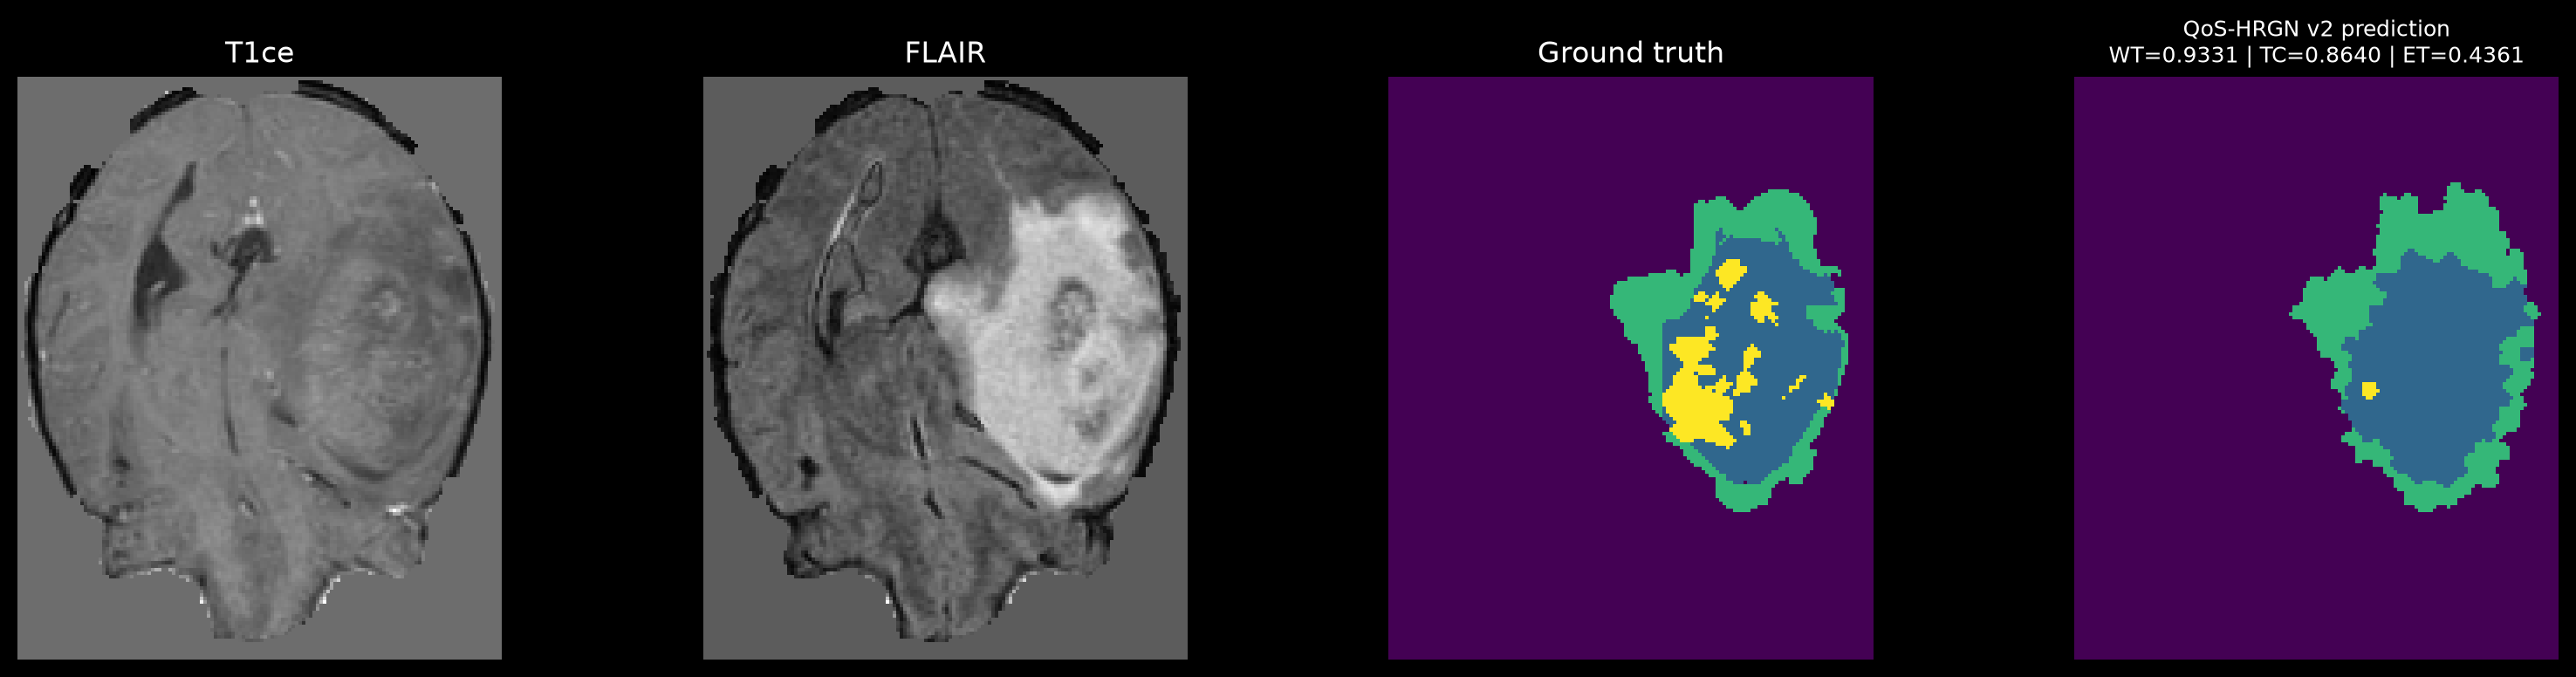

In [ ]:
def show_prediction(item, title="QoS-HRGN v2 prediction"):
    d, mpath = item
    meta = load_meta(mpath)
    pred = reconstruct_case(model, d, meta)
    lo, hi = meta["lo"], meta["hi"]
    seg_c = crop(meta["seg"], lo, hi)
    pred_c = crop(pred, lo, hi)
    z = int(np.argmax((seg_c > 0).sum(axis=(0, 1))))
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(meta["vis"]["t1ce"][:, :, z].astype(np.float32).T, cmap="gray", origin="lower"); ax[0].set_title("T1ce")
    ax[1].imshow(meta["vis"]["flair"][:, :, z].astype(np.float32).T, cmap="gray", origin="lower"); ax[1].set_title("FLAIR")
    ax[2].imshow(seg_c[:, :, z].T, cmap="viridis", origin="lower", vmin=0, vmax=3); ax[2].set_title("Ground truth")
    ax[3].imshow(pred_c[:, :, z].T, cmap="viridis", origin="lower", vmin=0, vmax=3)
    ax[3].set_title(f"{title}\n{fmt_metrics(segmentation_metrics(pred, meta['seg']))}", fontsize=9)
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

show_prediction(test_items[0])

## 14b. Option B: visualise initial vs refined prediction

In [ ]:
# ============================================================
# Option B: optional visualisation (not required for training)
# ============================================================
def show_structural_refinement(item, title="Option B: ground truth vs initial vs refined"):
    if not USE_STRUCTURAL_REFINEMENT:
        print("Structural refinement is disabled (USE_STRUCTURAL_REFINEMENT=False); nothing to visualise.")
        return
    d, mpath = item
    meta = load_meta(mpath)
    pred_init, pred_fin = reconstruct_case_both(model, d, meta, postprocess=True)
    seg = meta["seg"]
    z = int(np.argmax((seg > 0).sum(axis=(0, 1))))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, name in zip(
        axes, [seg[:, :, z], pred_init[:, :, z], pred_fin[:, :, z]],
        ["Ground truth", "Initial (pre-refinement)", "Refined (post-refinement)"],
    ):
        ax.imshow(img.T, cmap="viridis", vmin=0, vmax=NUM_CLASSES - 1, origin="lower")
        ax.set_title(name)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if USE_STRUCTURAL_REFINEMENT and test_items:
    show_structural_refinement(test_items[0])
else:
    print("Skipping visualisation (baseline mode, or no test cases available).")

Skipping visualisation (baseline mode, or no test cases available).


## 15. Save the trained model

In [ ]:
checkpoint = {
    "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    "class_weights": class_weights.detach().cpu(),
    "best_val_dice": best_val_dice,
    "best_epoch": best_epoch,
    "history": history,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "config": {
        "hidden_dim": HIDDEN_DIM, "heads": HEADS, "hops": HOPS, "hgt_layers": HGT_LAYERS, "dropout": DROPOUT,
        "num_classes": NUM_CLASSES, "node_features": NODE_FEAT_DIM, "n_segments": N_SEGMENTS,
        "compactness": COMPACTNESS, "slic_iters": SLIC_ITERS, "min_overlap": MIN_OVERLAP,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR, "dice_weight": DICE_WEIGHT,
        "et_min_voxels": ET_MIN_VOXELS, "graph_version": GRAPH_VERSION, "amp": USE_AMP,
    },
}
final_model_path = os.path.join(PERSISTENT_BASE, f"qos_hrgn_v2_slic{N_SEGMENTS}_hops{HOPS}.pt")
torch.save(checkpoint, final_model_path)
print(f"Saved: {final_model_path}")

## 17. Heterogeneous Graph Visualization

This section provides a research-grade visualization of the heterogeneous graph. Because the graph is massive (~15,000 nodes per modality), plotting the entire graph as a hairball is unreadable.

Instead, we provide:
1. **MRI-space local visualization**: Nodes and intra-modality spatial edges projected onto MRI slices, using slab-gating (only nodes near the slice are shown).
2. **Tumour-focused visualization**: Zooms into the bounding box of predicted tumour regions (WT, TC, ET) and explicitly highlights the cross-modal correspondence edges connecting T1ce to FLAIR.


In [ ]:
# ============================================================
# 17a. Local Graph & Tumour-Focused Visualization
# ============================================================
from matplotlib.collections import LineCollection
from matplotlib.patches import ConnectionPatch
from skimage.segmentation import find_boundaries

def _slab_mask(centroids_norm, crop_shape, z_slice, dz=1.5):
    """Boolean mask: which nodes have centroids within |z - z_slice| <= dz."""
    z_coords = centroids_norm[:, 2] * crop_shape[2]
    return np.abs(z_coords - z_slice) <= dz

def visualize_hetero_graph_slice(data, meta, z_slice=None, dz=1.5, max_cross_edges=30):
    """Side-by-side T1ce/FLAIR supervoxel graph overlaid on MRI axial slices."""
    lo, hi = meta["lo"], meta["hi"]
    crop_shape = tuple(hi - lo)
    seg_c = crop(meta["seg"], lo, hi)

    if z_slice is None:
        z_slice = int(np.argmax((seg_c > 0).sum(axis=(0, 1))))

    cent, slab, node_colors = {}, {}, {}
    CLASS_CMAP = np.array([[0.15, 0.15, 0.15, 0.7], [0.90, 0.30, 0.30, 0.9], [0.30, 0.80, 0.30, 0.9], [1.00, 0.85, 0.10, 0.9]])

    for nt in NODE_TYPES:
        c_norm = data[nt].x[:, -4:-1].cpu().numpy()
        cent[nt] = c_norm * np.array(crop_shape, dtype=np.float32)
        slab[nt] = _slab_mask(c_norm, crop_shape, z_slice, dz)
        node_colors[nt] = CLASS_CMAP[data[nt].y_frac.cpu().numpy().argmax(axis=1)]

    fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(14, 6))
    for nt, ax, color in [("t1ce", ax_t, "#00B8D4"), ("flair", ax_f, "#FF9100")]:
        ax.imshow(meta["vis"][nt][:, :, z_slice].astype(np.float32).T, cmap="gray", origin="lower")
        nm = meta["node_map"][nt]
        bnd = find_boundaries(nm[:, :, z_slice] if nm.ndim == 3 else nm[:, :, 0], mode="thin")
        overlay = np.zeros(bnd.shape + (4,), dtype=np.float32)
        overlay[bnd] = [1, 1, 1, 0.15]
        ax.imshow(overlay.transpose(1, 0, 2), origin="lower")

        ei_sp = data[(nt, "spatial", nt)].edge_index.cpu().numpy()
        valid_e = slab[nt][ei_sp[0]] & slab[nt][ei_sp[1]]
        segs = [[(cent[nt][u, 0], cent[nt][u, 1]), (cent[nt][v, 0], cent[nt][v, 1])] for u, v in ei_sp[:, valid_e].T]
        if segs: ax.add_collection(LineCollection(segs, colors=color, linewidths=0.7, alpha=0.35))

        idx = np.where(slab[nt])[0]
        if len(idx) > 0:
            ax.scatter(cent[nt][idx, 0], cent[nt][idx, 1], c=node_colors[nt][idx], s=15, edgecolors="white", linewidths=0.2, zorder=5)
        ax.axis("off"); ax.set_title(f"{nt.upper()} Graph (z={z_slice})")

    ei_cross = data[("t1ce", "corresponds", "flair")].edge_index.cpu().numpy()
    cross_pairs = ei_cross[:, slab["t1ce"][ei_cross[0]] & slab["flair"][ei_cross[1]]].T
    if len(cross_pairs) > max_cross_edges:
        cross_pairs = cross_pairs[np.random.choice(len(cross_pairs), max_cross_edges, replace=False)]

    for u, v in cross_pairs:
        fig.add_artist(ConnectionPatch(
            xyA=(cent["t1ce"][u, 0], cent["t1ce"][u, 1]), coordsA=ax_t.transData,
            xyB=(cent["flair"][v, 0], cent["flair"][v, 1]), coordsB=ax_f.transData,
            color="#E040FB", lw=1.0, linestyle="--", alpha=0.5, zorder=3))

    fig.suptitle(f"Heterogeneous Graph Visualization (Slab-gated z={z_slice}±{dz})", y=0.98)
    plt.tight_layout(); plt.show()


def visualize_tumour_subgraph(data, meta, logits, target_region="ET", z_slice=None, zoom_margin=15):
    """Zooms into a predicted tumour region and plots the dense local subgraph and cross-modal edges."""
    lo, hi = meta["lo"], meta["hi"]
    crop_shape = tuple(hi - lo)
    
    # Identify target nodes based on region (ET=3, TC=1+3, WT>0)
    pred_t1ce = logits["t1ce"].argmax(dim=-1).cpu().numpy()
    if target_region == "ET": mask = pred_t1ce == 3
    elif target_region == "TC": mask = (pred_t1ce == 1) | (pred_t1ce == 3)
    else: mask = pred_t1ce > 0
    
    if mask.sum() == 0:
        print(f"No {target_region} predicted to visualize.")
        return
        
    c_norm = data["t1ce"].x[:, -4:-1].cpu().numpy()
    cent_t1ce = c_norm * np.array(crop_shape, dtype=np.float32)
    
    target_cents = cent_t1ce[mask]
    if z_slice is None:
        z_slice = int(np.median(target_cents[:, 2]))
        
    target_in_slice = target_cents[np.abs(target_cents[:, 2] - z_slice) <= 2.0]
    if len(target_in_slice) == 0:
        target_in_slice = target_cents
        
    min_x, max_x = int(target_in_slice[:, 0].min()), int(target_in_slice[:, 0].max())
    min_y, max_y = int(target_in_slice[:, 1].min()), int(target_in_slice[:, 1].max())
    
    bbox = [max(0, min_x - zoom_margin), min(crop_shape[0], max_x + zoom_margin),
            max(0, min_y - zoom_margin), min(crop_shape[1], max_y + zoom_margin)]
            
    fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(10, 5))
    for nt, ax, color in [("t1ce", ax_t, "#00B8D4"), ("flair", ax_f, "#FF9100")]:
        ax.imshow(meta["vis"][nt][:, :, z_slice].astype(np.float32).T, cmap="gray", origin="lower")
        ax.set_xlim(bbox[0], bbox[1])
        ax.set_ylim(bbox[2], bbox[3])
        
        c = data[nt].x[:, -4:-1].cpu().numpy() * np.array(crop_shape, dtype=np.float32)
        in_box = (c[:, 0] >= bbox[0]) & (c[:, 0] <= bbox[1]) & (c[:, 1] >= bbox[2]) & (c[:, 1] <= bbox[3]) & (np.abs(c[:, 2] - z_slice) <= 1.5)
        
        ei_sp = data[(nt, "spatial", nt)].edge_index.cpu().numpy()
        valid_e = in_box[ei_sp[0]] & in_box[ei_sp[1]]
        segs = [[(c[u, 0], c[u, 1]), (c[v, 0], c[v, 1])] for u, v in ei_sp[:, valid_e].T]
        ax.add_collection(LineCollection(segs, colors=color, linewidths=1.0, alpha=0.5))
        
        idx = np.where(in_box)[0]
        if len(idx) > 0:
            pred_colors = np.array([[0.5,0.5,0.5], [0.9,0.3,0.3], [0.3,0.8,0.3], [1.0,0.85,0.1]])[logits[nt].argmax(dim=-1).cpu().numpy()[idx]]
            ax.scatter(c[idx, 0], c[idx, 1], c=pred_colors, s=30, edgecolors="white", zorder=5)
        ax.axis("off"); ax.set_title(f"{nt.upper()} Subgraph")
        
    ei_cross = data[("t1ce", "corresponds", "flair")].edge_index.cpu().numpy()
    c_f = data["flair"].x[:, -4:-1].cpu().numpy() * np.array(crop_shape, dtype=np.float32)
    in_box_t = (cent_t1ce[:, 0] >= bbox[0]) & (cent_t1ce[:, 0] <= bbox[1]) & (cent_t1ce[:, 1] >= bbox[2]) & (cent_t1ce[:, 1] <= bbox[3]) & (np.abs(cent_t1ce[:, 2] - z_slice) <= 1.5)
    
    valid_cross = in_box_t[ei_cross[0]] & mask[ei_cross[0]]
    for u, v in ei_cross[:, valid_cross].T:
        fig.add_artist(ConnectionPatch(
            xyA=(cent_t1ce[u, 0], cent_t1ce[u, 1]), coordsA=ax_t.transData,
            xyB=(c_f[v, 0], c_f[v, 1]), coordsB=ax_f.transData,
            color="#E040FB", lw=1.5, linestyle="solid", alpha=0.6, zorder=3))

    fig.suptitle(f"Tumour-Focused Subgraph (Region: {target_region})")
    plt.tight_layout(); plt.show()

if test_items:
    d, mp = test_items[0]
    logits, _ = model.base(d.to(device)) if hasattr(model, 'base') else model(d.to(device))
    visualize_hetero_graph_slice(d, load_meta(mp))
    visualize_tumour_subgraph(d, load_meta(mp), logits, target_region="WT")


## 18. Target-Specific Heterogeneous Graph Explainability

This module introduces a scientifically defensible explainability mechanism for the QoS-HRGN architecture. It answers: *"Which nodes and edges were most influential for a specific clinical prediction (WT, TC, ET)?"*

**Methodology:**
1. **Target Function Formulation:** We define $y_c$ as the sum of predicted logits for a target region (e.g., ET) over the nodes predicted as that region.
2. **Gradient Attribution (Input $\times$ Gradient):** For nodes, we compute $\sum_d |x_{v,d} \cdot \frac{\partial y_c}{\partial x_{v,d}}|$. For edges, we track the gradients of the adaptive propagation gates $\sigma_e$ and compute $|\sigma_e \cdot \frac{\partial y_c}{\partial \sigma_e}|$.
3. **Preservation of Heterogeneity:** The attribution explicitly preserves the T1ce/FLAIR separation and tracks intra-modal vs cross-modal edges individually.
4. **Faithfulness Check:** A perturbation-based test proves that masking the top-$k$% most "important" nodes drops the model's confidence significantly more than masking the bottom-$k$% nodes.


In [ ]:
# ============================================================
# 18a. Explainability Core (Input x Gradient & Gate Attribution)
# ============================================================
import types as _types_mod
from contextlib import contextmanager
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt

def _get_base_model(model_obj):
    return model_obj.base if hasattr(model_obj, "base") else model_obj

@contextmanager
def explainable_gate_capture(model_obj):
    """Context manager to capture gate values in AdaptiveHeteroPropagation WITH gradients."""
    base = _get_base_model(model_obj)
    captured_gates = {}
    originals = []

    for hop_idx, hop_layer in enumerate(base.adaptive):
        captured_gates[hop_idx] = {}
        _orig_hop_forward = hop_layer.forward

        def _make_patched_hop_forward(hop_ref, orig_fwd, gate_cap):
            def _patched_hop_forward(x_dict, edge_index_dict, edge_attr_dict, logits_dict):
                out = {nt: torch.zeros(x.size(0), x.size(1), device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}
                denom = {nt: torch.zeros(x.size(0), 1, device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}
                unc = {nt: -(torch.softmax(lg.float(), dim=-1).clamp_min(1e-8) * torch.softmax(lg.float(), dim=-1).clamp_min(1e-8).log()).sum(dim=-1) / math.log(lg.size(-1)) for nt, lg in logits_dict.items()}

                for et in hop_ref.edge_types:
                    src_t, rel, dst_t = et
                    key = "__".join(et)
                    ei = edge_index_dict[et]
                    if ei.numel() == 0: continue
                    src, dst = ei
                    hs, hd = x_dict[src_t][src].float(), x_dict[dst_t][dst].float()
                    ea = edge_attr_dict[et].float()
                    sim = F.cosine_similarity(hs, hd, dim=-1).unsqueeze(1)
                    cross = torch.full((ea.size(0), 1), 1.0 if rel == "corresponds" else 0.0, device=hs.device)
                    u = ((unc[src_t][src] + unc[dst_t][dst]) / 2).unsqueeze(1)

                    alpha = torch.sigmoid(hop_ref.gate[key](torch.cat([hs, hd, ea, sim, cross, u], dim=1))).float()
                    # Retain gradients for attribution
                    alpha.retain_grad()
                    gate_cap[et] = alpha
                    
                    msg = (hop_ref.msg[key](hs).float() * alpha)
                    out[dst_t].index_add_(0, dst, msg)
                    denom[dst_t].index_add_(0, dst, alpha)

                return {nt: hop_ref.norm[nt](x_dict[nt].float() + hop_ref.drop(F.relu(out[nt] / (denom[nt] + 1.0)))) for nt in x_dict}
            return _patched_hop_forward

        hop_layer.forward = _make_patched_hop_forward(hop_layer, _orig_hop_forward, captured_gates[hop_idx])
        originals.append((hop_layer, _orig_hop_forward))

    try:
        yield captured_gates
    finally:
        for layer, orig_fwd in originals:
            layer.forward = orig_fwd

def generate_graph_explanation(model, data, target_region="ET"):
    """
    Computes Input x Gradient attribution for nodes and Activation x Gradient for edges.
    Target Region: WT (1,2,3), TC (1,3), or ET (3).
    """
    model.eval()
    d = data.clone().to(device)
    for nt in NODE_TYPES:
        d[nt].x = d[nt].x.clone().detach().requires_grad_(True)
        
    model.zero_grad()
    
    with explainable_gate_capture(model) as gate_caps:
        if USE_STRUCTURAL_REFINEMENT:
            _, logits, _ = model(d, teacher_prob=0.0)
        else:
            logits, _ = _get_base_model(model)(d)
            
    # Define target mask and compute score
    score = 0.0
    masks = {}
    if target_region == "ET": tc = [3]
    elif target_region == "TC": tc = [1, 3]
    else: tc = [1, 2, 3]
    
    for nt in NODE_TYPES:
        pred = logits[nt].argmax(dim=-1)
        if target_region == "ET": mask = (pred == 3)
        elif target_region == "TC": mask = (pred == 1) | (pred == 3)
        else: mask = (pred > 0)
        masks[nt] = mask
        if mask.sum() > 0:
            for c in tc:
                score = score + logits[nt][mask, c].sum()
                
    if isinstance(score, float) or score == 0.0 or not score.requires_grad:
        return None  # Region not predicted
        
    score.backward()
    
    # Calculate Importance
    node_imp, edge_imp = {}, {}
    for nt in NODE_TYPES:
        grad = d[nt].x.grad
        imp = (grad * d[nt].x).sum(dim=-1).abs().cpu().numpy()
        node_imp[nt] = imp
        
    last_hop = max(gate_caps.keys())
    for et, gate in gate_caps[last_hop].items():
        if gate.grad is not None:
            imp = (gate.grad * gate).sum(dim=-1).abs().cpu().numpy()
            edge_imp[et] = imp
            
    return {"score": float(score), "node_imp": node_imp, "edge_imp": edge_imp, "masks": {nt: m.cpu().numpy() for nt, m in masks.items()}}


In [ ]:
# ============================================================
# 18b. Explanatory Visualization & Faithfulness Testing
# ============================================================

def visualize_explanation(data, meta, exp, target_region="ET", top_k_nodes=200):
    """Visualizes the most important graph components underlying the target prediction."""
    if exp is None: return
    
    lo, hi = meta["lo"], meta["hi"]
    crop_shape = tuple(hi - lo)
    z_slice = int(np.argmax((meta["seg"] > 0).sum(axis=(0, 1))))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(meta["vis"]["t1ce"][:, :, z_slice].astype(np.float32).T, cmap="gray", origin="lower")
    axes[0].imshow(crop(meta["seg"], lo, hi)[:, :, z_slice].T, cmap="viridis", alpha=0.4, origin="lower")
    axes[0].set_title(f"Ground Truth & MRI (z={z_slice})"); axes[0].axis("off")
    
    for idx, nt in enumerate(NODE_TYPES):
        ax = axes[idx + 1]
        ax.imshow(meta["vis"][nt][:, :, z_slice].astype(np.float32).T, cmap="gray", origin="lower")
        
        c = data[nt].x[:, -4:-1].cpu().numpy() * np.array(crop_shape, dtype=np.float32)
        imp = exp["node_imp"][nt]
        
        # Plot top nodes
        top_idx = np.argsort(imp)[-top_k_nodes:]
        in_slice = np.abs(c[top_idx, 2] - z_slice) <= 2.0
        top_idx = top_idx[in_slice]
        
        if len(top_idx) > 0:
            sizes = 10 + 90 * (imp[top_idx] / imp.max())
            ax.scatter(c[top_idx, 0], c[top_idx, 1], c=imp[top_idx], cmap="magma", s=sizes, edgecolors="white", zorder=5)
            
        ax.set_title(f"{nt.upper()} Important Nodes (Target: {target_region})")
        ax.axis("off")
        
    fig.suptitle(f"Graph Explainability - Input x Gradient Attribution (Score: {exp['score']:.1f})")
    plt.tight_layout(); plt.show()


def evaluate_faithfulness(model, data, exp, target_region="ET", k_percent=0.10):
    """
    Sanity check: Masking the top-K% most important nodes should drop the 
    prediction score significantly more than masking the bottom-K%.
    """
    if exp is None: return None
    
    base_score = exp["score"]
    all_imp = np.concatenate([exp["node_imp"][nt] for nt in NODE_TYPES])
    thresh_top = np.percentile(all_imp, 100 - (k_percent * 100))
    thresh_bot = np.percentile(all_imp[all_imp > 0], k_percent * 100) # bottom among active
    
    results = {}
    for label, thresh, mode in [("top", thresh_top, ">="), ("bot", thresh_bot, "<=")]:
        d_mask = data.clone().to(device)
        for nt in NODE_TYPES:
            mask_idx = exp["node_imp"][nt] >= thresh if mode == ">=" else exp["node_imp"][nt] <= thresh
            d_mask[nt].x = d_mask[nt].x.clone()
            d_mask[nt].x[mask_idx] = 0.0
            
        with torch.no_grad():
            if USE_STRUCTURAL_REFINEMENT: _, lg, _ = model(d_mask, teacher_prob=0.0)
            else: lg, _ = _get_base_model(model)(d_mask)
            
        new_score = 0.0
        tc = [3] if target_region == "ET" else ([1, 3] if target_region == "TC" else [1, 2, 3])
        for nt in NODE_TYPES:
            m = exp["masks"][nt]
            if m.sum() > 0:
                for c in tc: new_score += lg[nt][m, c].sum().item()
        results[f"drop_{label}"] = base_score - new_score
        
    return results


def run_explainability_pipeline(items, target_region="WT"):
    """Runs visualization, attribution, and quantitative faithfulness check."""
    print(f"=== Quantitative Explainability Summary (Target: {target_region}) ===")
    faith_drops_top = []
    faith_drops_bot = []
    
    for d, mpath in items[:5]:
        d = d.to(device)
        exp = generate_graph_explanation(model, d, target_region=target_region)
        if exp is None: continue
        
        visualize_explanation(d, load_meta(mpath), exp, target_region=target_region)
        faith = evaluate_faithfulness(model, d, exp, target_region=target_region)
        
        faith_drops_top.append(faith["drop_top"] / exp["score"])
        faith_drops_bot.append(faith["drop_bot"] / exp["score"])
        
        # Edge importance stats
        sp_imp = np.concatenate([exp["edge_imp"][et] for et in exp["edge_imp"] if et[1] == "spatial"]).mean()
        cr_imp = np.concatenate([exp["edge_imp"][et] for et in exp["edge_imp"] if et[1] == "corresponds"]).mean()
        print(f"-> Edge Importance (Mean) | Spatial: {sp_imp:.4f} | Cross-Modal: {cr_imp:.4f}")
        
    print(f"\nFaithfulness Check (Masking top/bot 10% nodes):")
    print(f"  Avg Score Drop (Top 10% masked): {np.mean(faith_drops_top)*100:.1f}%")
    print(f"  Avg Score Drop (Bot 10% masked): {np.mean(faith_drops_bot)*100:.1f}%")
    if np.mean(faith_drops_top) > np.mean(faith_drops_bot):
        print("  ✓ Faithfulness verified: Attributed nodes strongly control the prediction.")

if test_items:
    run_explainability_pipeline(test_items, target_region="WT")
    run_explainability_pipeline(test_items, target_region="TC")
    run_explainability_pipeline(test_items, target_region="ET")
